# 🔎 **Clustering Analysis: GLM and GAM**  
***
This notebook aims to analyze the chemical characteristics underlying the optimized clusters obtained from the Clustering+GLM and Clustering+GAM models. Here, we focus on the clusters that concentrate instances with higher critical temperatures (Tc above 77 K).

### 📚 **Importing libraries & Data**

First of all, we need to import all necessary libraries and the data (from UCI Repository)

In [214]:
import optuna

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.cluster import Birch, BisectingKMeans
from sklearn.preprocessing import StandardScaler

from statsmodels.genmod.families.links import Identity
import statsmodels.api as sm

import pygam
from pygam import s

import shap

import shapiq

In [215]:
df = pd.read_csv("../data/train.csv")
display(df)

,number_of_elements,mean_atomic_mass,wtd_mean_atomic_mass,gmean_atomic_mass,wtd_gmean_atomic_mass,entropy_atomic_mass,wtd_entropy_atomic_mass,range_atomic_mass,wtd_range_atomic_mass,std_atomic_mass,...,wtd_mean_Valence,gmean_Valence,wtd_gmean_Valence,entropy_Valence,wtd_entropy_Valence,range_Valence,wtd_range_Valence,std_Valence,wtd_std_Valence,critical_temp
0,4,88.944468,57.862692,66.361592,36.116612,1.181795,1.062396,122.90607,31.794921,51.968828,...,2.257143,2.213364,2.219783,1.368922,1.066221,1,1.085714,0.433013,0.437059,29.00
1,5,92.729214,58.518416,73.132787,36.396602,1.449309,1.057755,122.90607,36.161939,47.094633,...,2.257143,1.888175,2.210679,1.557113,1.047221,2,1.128571,0.632456,0.468606,26.00
2,4,88.944468,57.885242,66.361592,36.122509,1.181795,0.975980,122.90607,35.741099,51.968828,...,2.271429,2.213364,2.232679,1.368922,1.029175,1,1.114286,0.433013,0.444697,19.00
3,4,88.944468,57.873967,66.361592,36.119560,1.181795,1.022291,122.90607,33.768010,51.968828,...,2.264286,2.213364,2.226222,1.368922,1.048834,1,1.100000,0.433013,0.440952,22.00
4,4,88.944468,57.840143,66.361592,36.110716,1.181795,1.129224,122.90607,27.848743,51.968828,...,2.242857,2.213364,2.206963,1.368922,1.096052,1,1.057143,0.433013,0.428809,23.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21258,4,106.957877,53.095769,82.515384,43.135565,1.177145,1.254119,146.88130,15.504479,65.764081,...,3.555556,3.223710,3.519911,1.377820,0.913658,1,2.168889,0.433013,0.496904,2.44
21259,5,92.266740,49.021367,64.812662,32.867748,1.323287,1.571630,188.38390,7.353333,69.232655,...,2.047619,2.168944,2.038991,1.594167,1.337246,1,0.904762,0.400000,0.212959,122.10
21260,2,99.663190,95.609104,99.433882,95.464320,0.690847,0.530198,13.51362,53.041104,6.756810,...,4.800000,4.472136,4.781762,0.686962,0.450561,1,3.200000,0.500000,0.400000,1.98
21261,2,99.663190,97.095602,99.433882,96.901083,0.690847,0.640883,13.51362,31.115202,6.756810,...,4.690000,4.472136,4.665819,0.686962,0.577601,1,2.210000,0.500000,0.462493,1.84


In [216]:
TEST_SIZE = 0.1

In [217]:
X = df.drop(columns="critical_temp")
y = df["critical_temp"]
X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=TEST_SIZE, random_state=1702
    )
y_test = np.clip(y_test, 1e-6, None)
y_train = np.clip(y_train, 1e-6, None)

### **GLM**

Now, we need to verify which clusters contain high temperature superconductors. For this, we will plot a critical temperature distributior for each cluster (as we did in ``Exploring_interpretability`` notebook).

In [218]:
study_name = "optimization_clusters_glm_teste21_07_2025_16_46_28"
storage_url = "sqlite:///../Optuna_files/optimization_glm_bayesian.db"

study_glm_bs = optuna.load_study(study_name=study_name, storage=storage_url)

In [219]:
study_glm_bs.best_params

{'clusterer': 'birch',
 'n_clusters_birch': 10,
 'branching_factor': 700,
 'threshold': 0.18251719168858943,
 'distribution': 'gaussian',
 'link_gaussian': 'identity'}

In [220]:
birch_glm = Birch(n_clusters=10,
                    branching_factor=700,
                    threshold=0.18251719168858943)

In [221]:
cluster_labels_glm = birch_glm.fit_predict(X_train)

unique_clusters_glm = np.unique(cluster_labels_glm)
valid_clusters_glm = [c for c in unique_clusters_glm if c != -1]

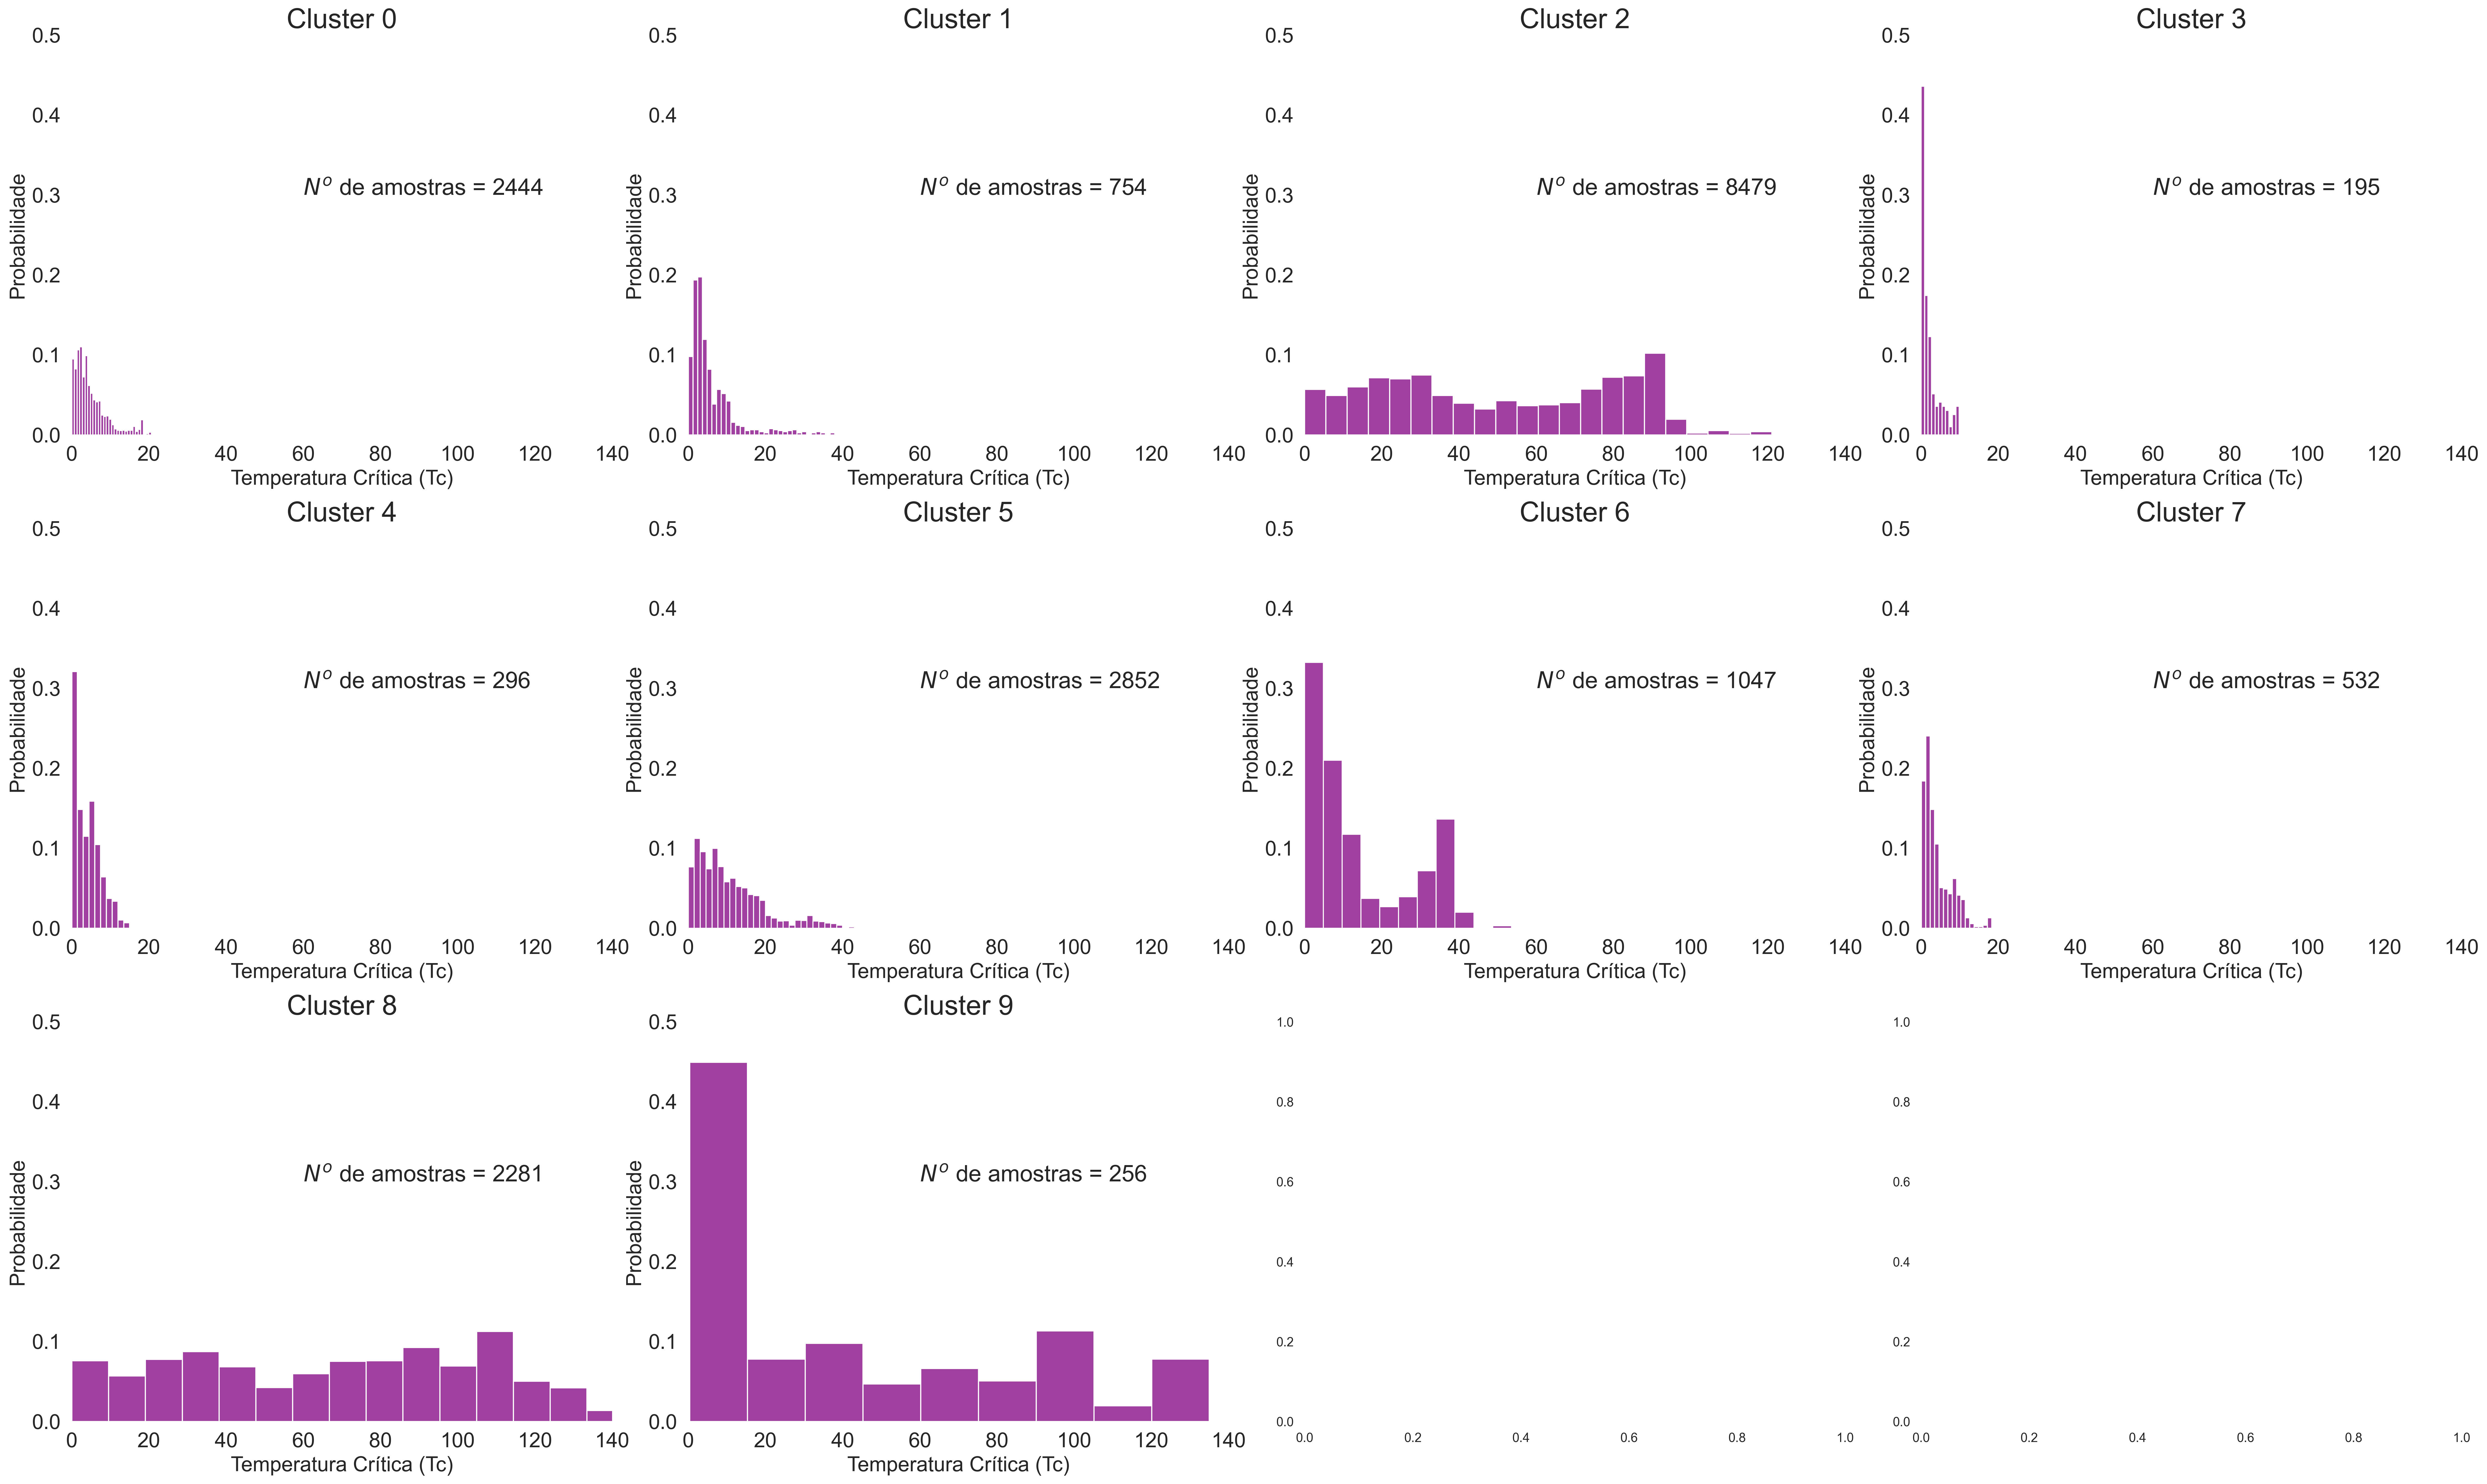

In [222]:
fig, axs = plt.subplots(3, 4, figsize=(30, 18), dpi=300)
axs = axs.flatten()

count = 0
for cluster in valid_clusters_glm: 
    idx = np.where(cluster_labels_glm == cluster)[0]

    X_cluster = X_train.iloc[idx]
    y_cluster = y_train.iloc[idx]

    sns.histplot(y_cluster, ax=axs[count], kde=False, stat="probability", color="purple") 
    coord_x = max(y_cluster)/2 
    axs[count].annotate(fr"$N^o$ de amostras = {len(y_cluster)}", xy=(60, 0.3), fontsize=20)
    axs[count].set_title(f"Cluster {cluster}", fontsize=24)
    axs[count].set_xlim(0, 140)
    axs[count].set_ylim(0, 0.5)
    axs[count].tick_params(axis='both', labelsize=18) 
    axs[count].set_ylabel("Probabilidade", fontsize=18)
    axs[count].set_xlabel("Temperatura Crítica (Tc)", fontsize=18)

    count += 1
    if count >= len(X_train.columns): 
        break

plt.tight_layout()
plt.show()

Clusters 2, 8, and 9 stand out for containing the highest concentration of high-temperature superconductors. So let´s investigate!

The first step is to import the dataset that contains the chemical formula of the supercondutors.

In [223]:
df_cf = pd.read_csv("../data/unique_m.csv")
display(df_cf)

,H,He,Li,Be,B,C,N,O,F,Ne,...,Au,Hg,Tl,Pb,Bi,Po,At,Rn,critical_temp,material
0,0.0,0,0.0,0.0,0.0,0.0,0.0,4.0,0.0,0,...,0.0,0.0,0.0,0.0,0.0,0,0,0,29.00,Ba0.2La1.8Cu1O4
1,0.0,0,0.0,0.0,0.0,0.0,0.0,4.0,0.0,0,...,0.0,0.0,0.0,0.0,0.0,0,0,0,26.00,Ba0.1La1.9Ag0.1Cu0.9O4
2,0.0,0,0.0,0.0,0.0,0.0,0.0,4.0,0.0,0,...,0.0,0.0,0.0,0.0,0.0,0,0,0,19.00,Ba0.1La1.9Cu1O4
3,0.0,0,0.0,0.0,0.0,0.0,0.0,4.0,0.0,0,...,0.0,0.0,0.0,0.0,0.0,0,0,0,22.00,Ba0.15La1.85Cu1O4
4,0.0,0,0.0,0.0,0.0,0.0,0.0,4.0,0.0,0,...,0.0,0.0,0.0,0.0,0.0,0,0,0,23.00,Ba0.3La1.7Cu1O4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21258,0.0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,...,0.0,0.0,0.0,0.0,0.0,0,0,0,2.44,Tm0.84Lu0.16Fe3Si5
21259,0.0,0,0.0,0.0,0.0,0.0,0.0,11.0,0.0,0,...,0.0,0.0,1.0,0.0,0.0,0,0,0,122.10,Tl1Ba2Ca3Cu4O11
21260,0.0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,...,0.0,0.0,0.0,0.0,0.0,0,0,0,1.98,Nb0.8Pd0.2
21261,0.0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,...,0.0,0.0,0.0,0.0,0.0,0,0,0,1.84,Nb0.69Pd0.31


Now, we need to split the dataset as we made with the original data.

In [224]:
Xe = df_cf.drop(columns=["critical_temp", "material"])
ye = df_cf["critical_temp"]

Xe_train, Xe_test, ye_train, ye_test = train_test_split(
        Xe, ye, test_size=TEST_SIZE, random_state=1702
    )
ye_test = np.clip(ye_test, 1e-6, None)
ye_train = np.clip(ye_train, 1e-6, None)

In [225]:
Xe_train

,H,He,Li,Be,B,C,N,O,F,Ne,...,Ir,Pt,Au,Hg,Tl,Pb,Bi,Po,At,Rn
907,0.0,0,0.0,0.0,0.0,0.0,0.0,1.000,0.0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0
12566,0.0,0,0.0,0.0,0.0,0.0,0.0,0.000,0.0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0
20091,0.0,0,0.0,0.0,0.0,0.0,0.0,0.000,0.0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0
5751,0.0,0,0.0,0.0,0.0,0.0,0.0,4.000,0.0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0
16819,0.0,0,0.0,0.0,0.0,0.0,0.0,0.000,0.0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7270,0.0,0,0.0,0.0,0.0,0.0,0.0,6.556,0.0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0
21168,0.0,0,0.0,0.0,0.0,0.0,0.0,0.000,0.0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0
13381,0.0,0,0.0,0.0,0.0,0.0,0.0,0.000,0.0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0
6874,0.0,0,0.0,0.0,0.0,0.0,0.0,4.000,0.0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0


In [226]:
idx2 = np.where(cluster_labels_glm == 2)[0]
Xe2 = Xe_train.iloc[idx2]
display(Xe2)

idx8 = np.where(cluster_labels_glm == 8)[0]
Xe8 = Xe_train.iloc[idx8]
display(Xe8)

idx9 = np.where(cluster_labels_glm == 9)[0]
Xe9 = Xe_train.iloc[idx9]
display(Xe9)


,H,He,Li,Be,B,C,N,O,F,Ne,...,Ir,Pt,Au,Hg,Tl,Pb,Bi,Po,At,Rn
907,0.0,0,0.0,0.0,0.0,0.0,0.0,1.000,0.0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0
5751,0.0,0,0.0,0.0,0.0,0.0,0.0,4.000,0.0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0
19836,0.0,0,0.0,0.0,0.0,0.0,0.0,1.000,0.0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0
1197,0.0,0,0.0,0.0,0.0,0.0,0.0,7.000,0.0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0
17676,0.0,0,0.0,0.0,0.0,0.0,0.0,3.908,0.0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10346,0.0,0,0.0,0.0,0.0,0.0,0.0,1.000,0.0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0
18675,0.0,0,0.0,0.0,0.0,0.0,0.0,4.000,0.0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0
7270,0.0,0,0.0,0.0,0.0,0.0,0.0,6.556,0.0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0
6874,0.0,0,0.0,0.0,0.0,0.0,0.0,4.000,0.0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0


,H,He,Li,Be,B,C,N,O,F,Ne,...,Ir,Pt,Au,Hg,Tl,Pb,Bi,Po,At,Rn
7641,0.0,0,0.0,0.0,0.0,0.0,0.0,4.2800,0.0000,0,...,0.0,0.0,0.0,1.0,0.0,0.00,0.0,0,0,0
3691,0.0,0,0.0,0.0,0.0,0.0,0.0,4.0000,0.0000,0,...,0.0,0.0,0.0,0.9,0.0,0.00,0.0,0,0,0
8532,0.0,0,0.0,0.0,0.0,0.0,0.0,1.0000,0.0000,0,...,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0,0,0
5248,0.0,0,0.0,0.0,0.0,0.0,0.0,7.2608,1.0031,0,...,0.0,0.0,0.0,0.0,0.0,2.00,0.0,0,0,0
5591,0.0,0,0.0,0.0,0.0,0.0,0.0,4.0970,0.0000,0,...,0.0,0.0,0.0,1.0,0.0,0.00,0.0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1565,0.0,0,0.0,0.0,0.0,0.0,0.0,6.0000,0.0000,0,...,0.0,0.0,0.0,0.0,0.0,1.00,1.0,0,0,0
5170,0.0,0,0.0,0.0,0.0,0.0,0.0,1.0000,0.0000,0,...,0.0,0.0,0.0,0.0,0.5,0.00,0.0,0,0,0
990,0.0,0,0.0,0.0,0.0,0.0,0.0,8.0000,0.0000,0,...,0.0,0.0,0.0,0.0,2.0,0.00,0.0,0,0,0
5211,0.0,0,0.0,0.0,0.0,0.0,0.0,1.0000,0.0000,0,...,0.0,0.0,0.0,0.0,0.0,0.40,1.6,0,0,0


,H,He,Li,Be,B,C,N,O,F,Ne,...,Ir,Pt,Au,Hg,Tl,Pb,Bi,Po,At,Rn
4399,0.0,0,0.0,0.0,0.0,0.0,0.0,6.00,0.0,0,...,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0,0,0
13242,0.0,0,0.0,0.0,0.0,0.0,0.0,3.00,0.0,0,...,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0,0,0
11096,0.0,0,0.0,0.0,0.0,0.0,0.0,6.00,0.0,0,...,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0,0,0
11433,0.0,0,0.0,0.0,0.0,0.0,0.0,3.00,0.0,0,...,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0,0,0
13220,0.0,0,0.0,0.0,0.0,0.0,0.0,3.00,0.0,0,...,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4554,0.0,0,0.0,0.0,0.0,0.0,0.0,1.00,0.0,0,...,0.0,0.0,0.3,0.7,0.00,0.0,0.0,0,0,0
15409,0.0,0,0.1,0.0,0.0,0.0,0.0,2.80,0.2,0,...,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0,0,0
8642,0.0,0,0.0,0.0,0.0,0.0,0.0,4.42,0.0,0,...,0.0,0.0,0.0,0.9,0.00,0.0,0.0,0,0,0
20307,0.0,0,0.0,0.0,0.0,0.0,0.0,8.00,0.0,0,...,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0,0,0


By that, we can use these datasets to identify the presence of elements in the chemical formula and respond the question: is there an evident pattern in the clusters formed?

In [227]:
# X2
elements_x2 = {}
for element in Xe.columns:
    elements_x2[element] = 0

for idx in range(len(Xe2)):
    formulas = Xe2.iloc[idx][Xe2.iloc[idx] != 0].index
    for element in formulas:
        elements_x2[element] += 1

# X8
elements_x8 = {}
for element in Xe.columns:
    elements_x8[element] = 0

for idx in range(len(Xe8)):
    formulas = Xe8.iloc[idx][Xe8.iloc[idx] != 0].index
    for element in formulas:
        elements_x8[element] += 1

# X9
elements_x9 = {}
for element in Xe.columns:
    elements_x9[element] = 0

for idx in range(len(Xe9)):
    formulas = Xe9.iloc[idx][Xe9.iloc[idx] != 0].index
    for element in formulas:
        elements_x9[element] += 1

Let´s plot!

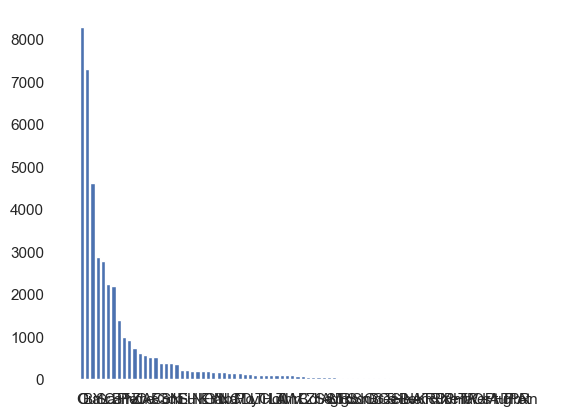

In [228]:
elements_x2_ord = dict(sorted(elements_x2.items(), key=lambda item: item[1], reverse=True))

plt.bar(elements_x2_ord.keys(), elements_x2_ord.values());
plt.show()

It's hard to visualize this because many elements that appear as columns in the original dataset are not present in the chemical formula of this group. Therefore, we will filter the data to retain only the elements that are actually significant.

In [229]:
for element in Xe.columns:
    if elements_x2[element] == 0:
        elements_x2.pop(element, None)

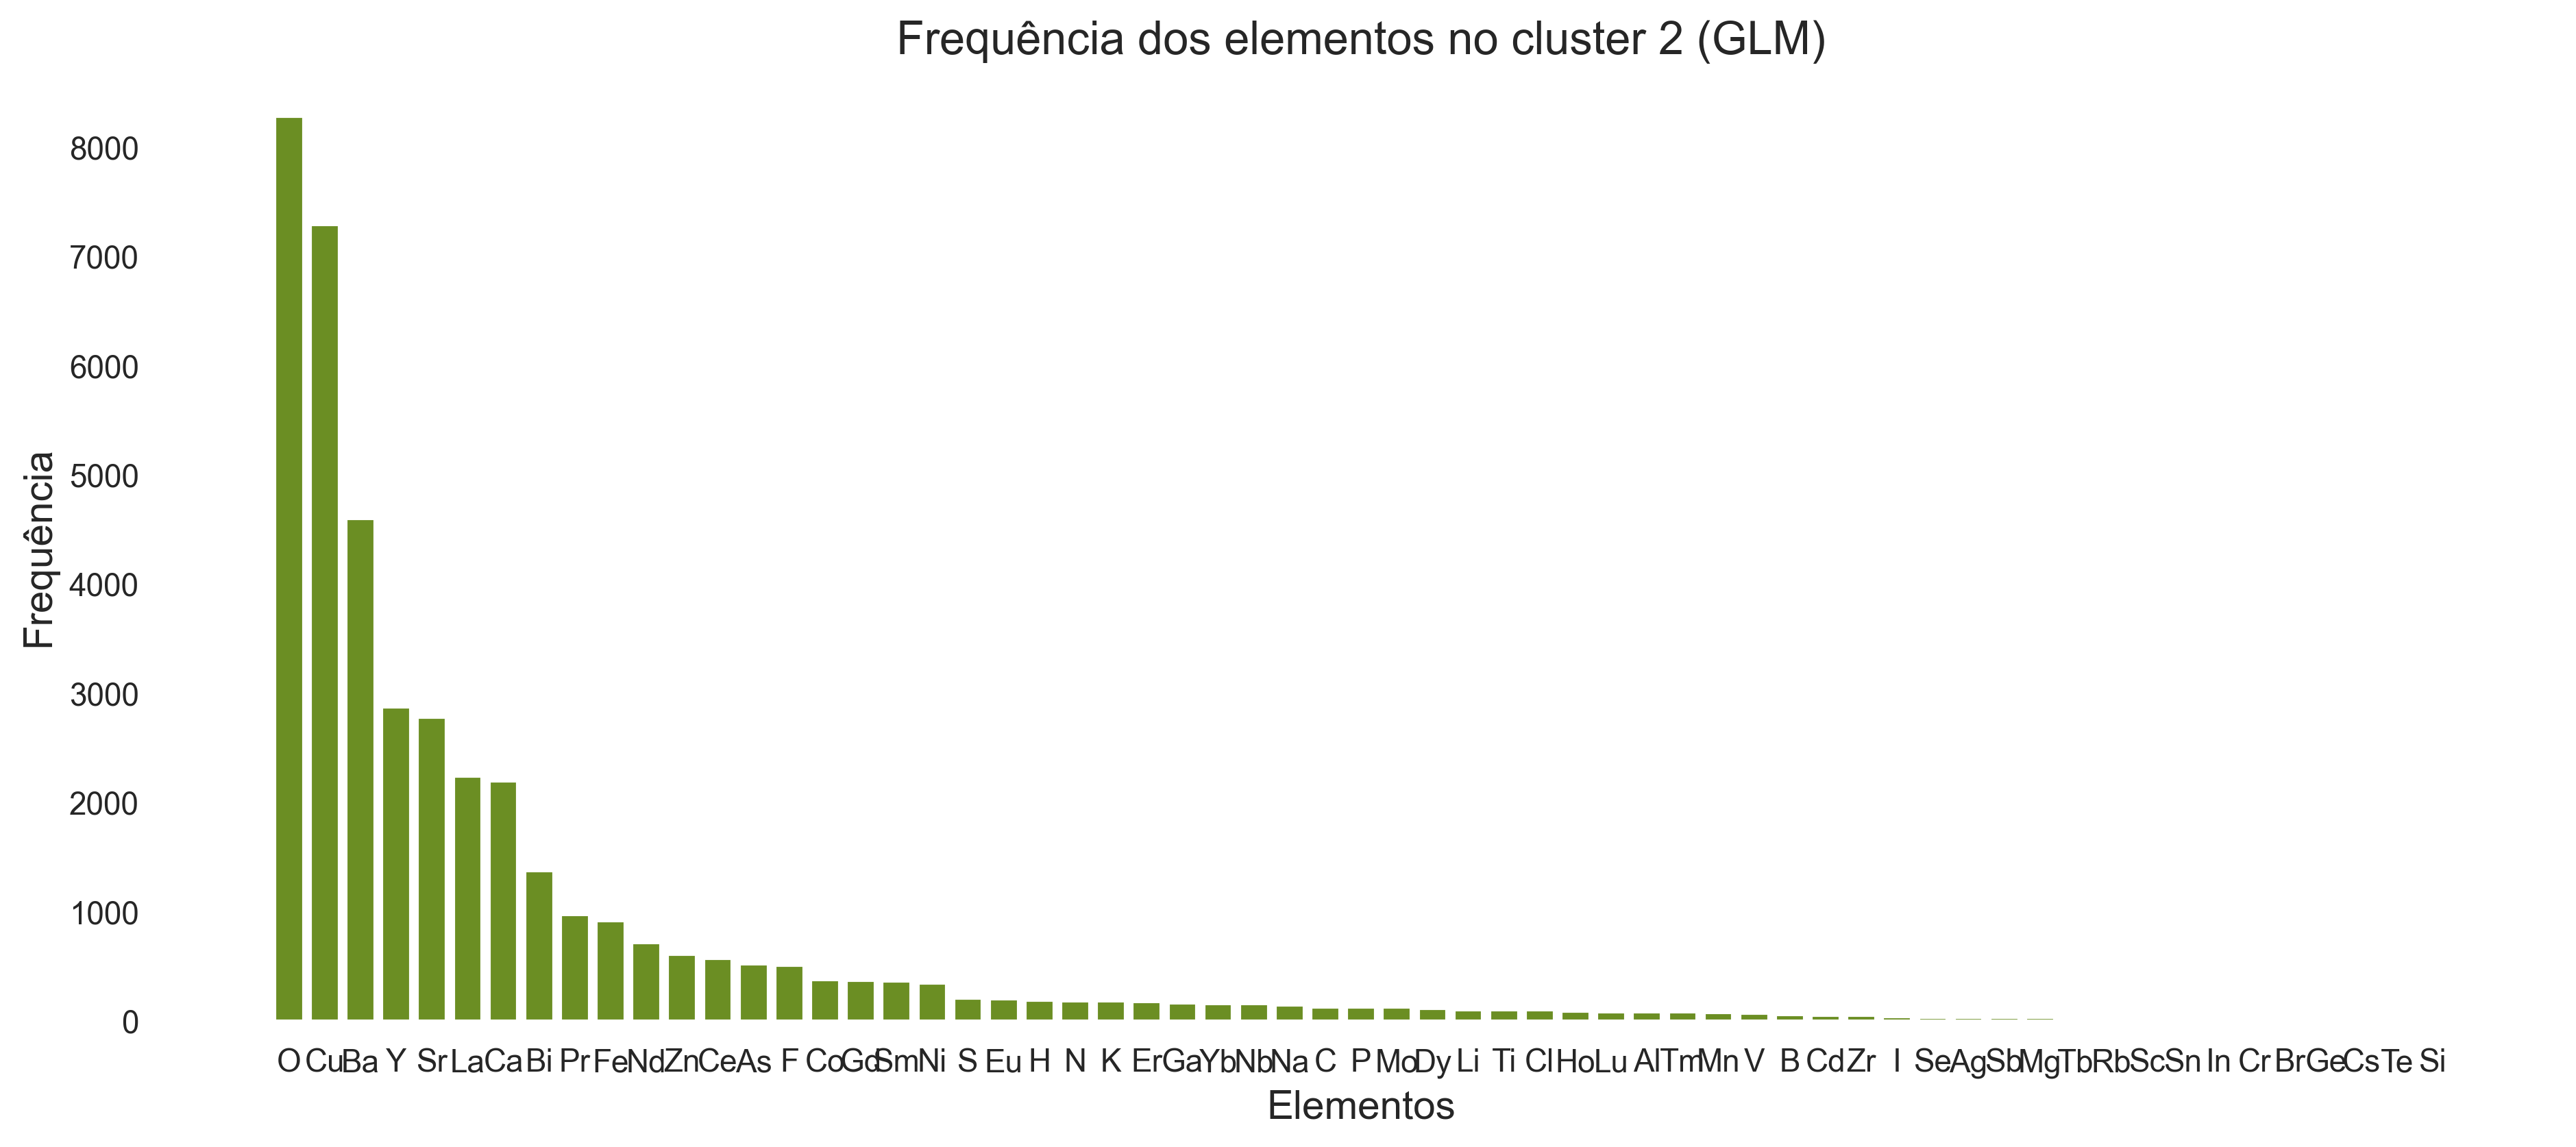

In [230]:
elements_x2_ord = dict(sorted(elements_x2.items(), key=lambda item: item[1], reverse=True))

plt.figure(figsize=(15, 6), dpi=300)

plt.bar(elements_x2_ord.keys(), elements_x2_ord.values(), color="olivedrab");
plt.xlabel("Elementos", fontsize=14)
plt.ylabel("Frequência", fontsize=14)
plt.title("Frequência dos elementos no cluster 2 (GLM)", fontsize=16)
plt.show()

Now, let´s do the same to the others clusters.

In [231]:
for element in Xe.columns:
    if elements_x8[element] == 0:
        elements_x8.pop(element, None)

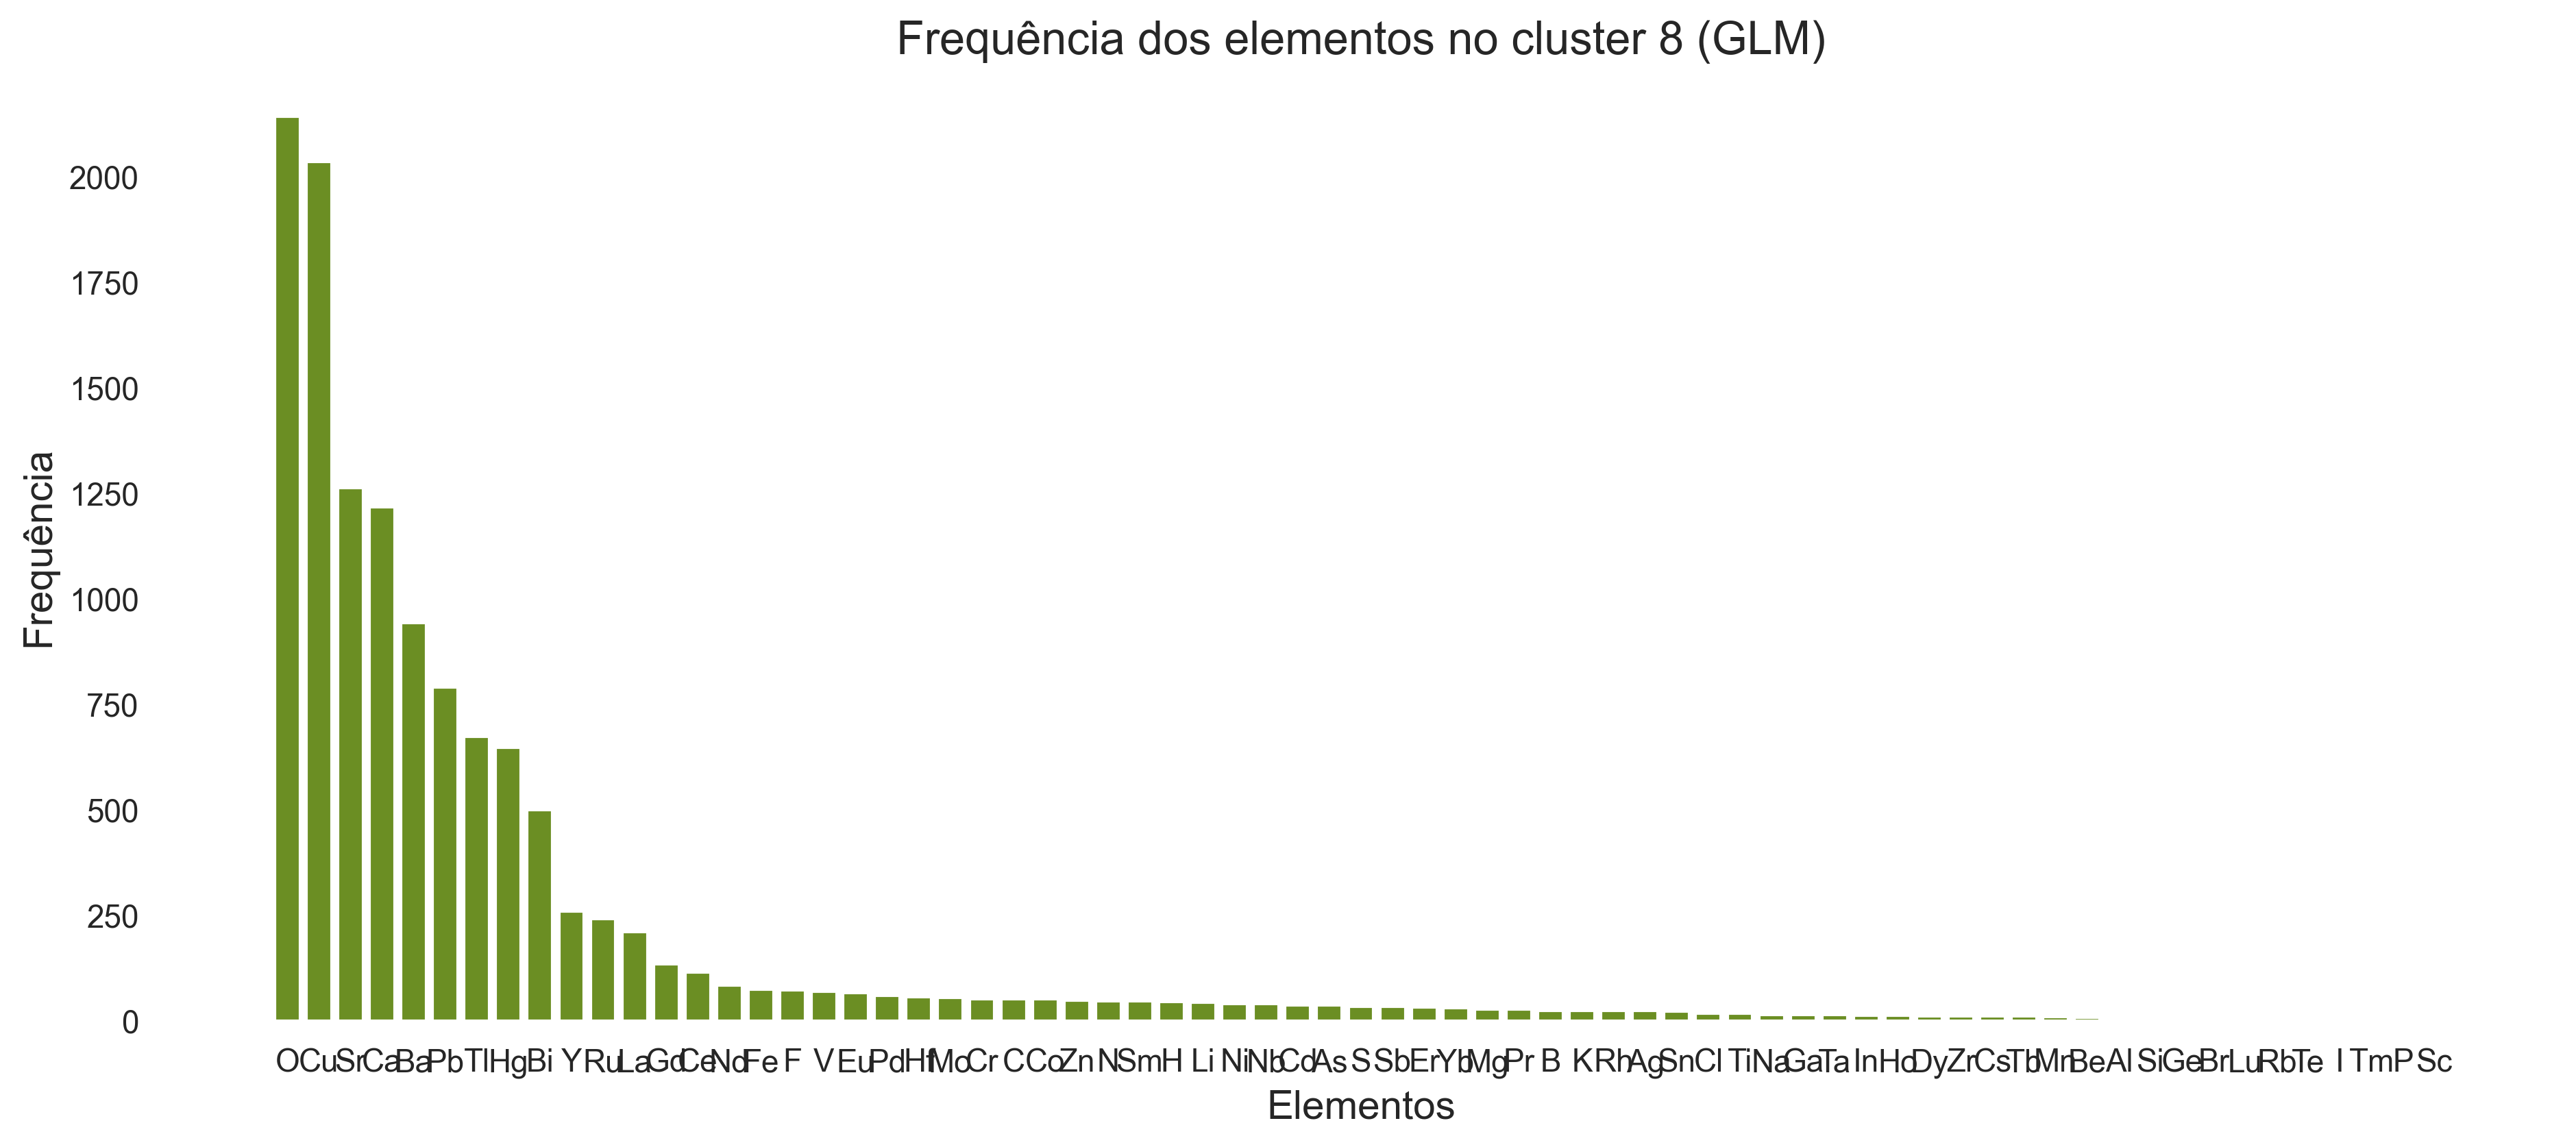

In [232]:
elements_x8_ord = dict(sorted(elements_x8.items(), key=lambda item: item[1], reverse=True))

plt.figure(figsize=(15, 6), dpi=300)

plt.bar(elements_x8_ord.keys(), elements_x8_ord.values(), color="olivedrab");
plt.xlabel("Elementos", fontsize=14)
plt.ylabel("Frequência", fontsize=14)
plt.title("Frequência dos elementos no cluster 8 (GLM)", fontsize=16)
plt.show()

In [233]:
for element in Xe.columns:
    if elements_x9[element] == 0:
        elements_x9.pop(element, None)

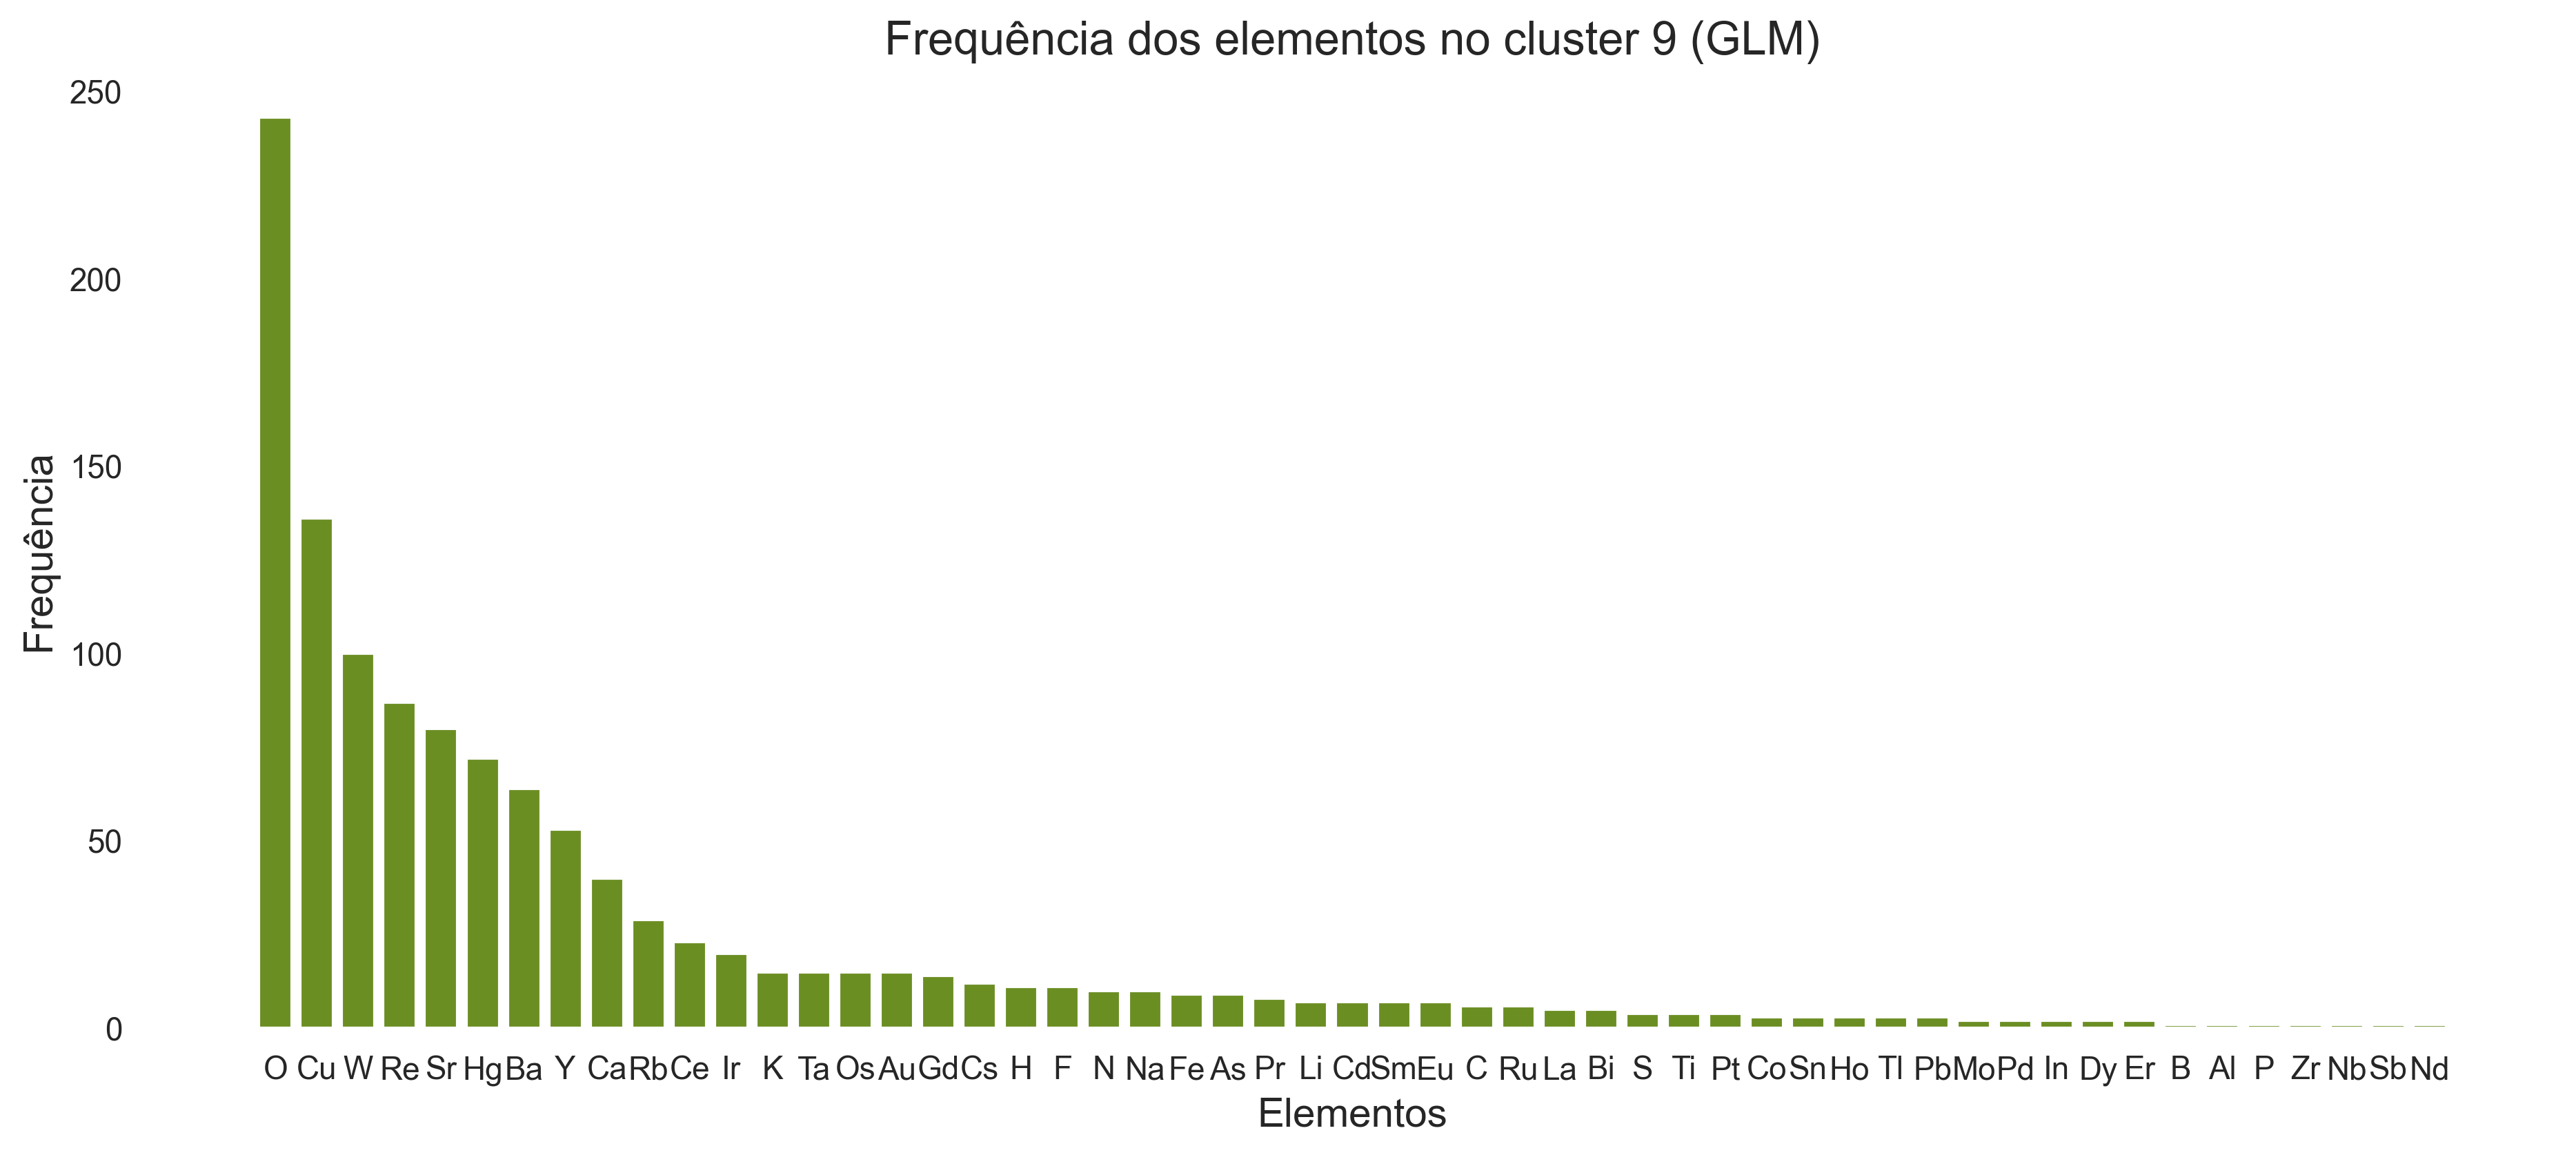

In [234]:
elements_x9_ord = dict(sorted(elements_x9.items(), key=lambda item: item[1], reverse=True))

plt.figure(figsize=(15, 6), dpi=300)

plt.bar(elements_x9_ord.keys(), elements_x9_ord.values(), color="olivedrab");
plt.xlabel("Elementos", fontsize=14)
plt.ylabel("Frequência", fontsize=14)
plt.title("Frequência dos elementos no cluster 9 (GLM)", fontsize=16)
plt.show()

Another relevant analysis is to evaluate the most important feature overall within each cluster. Based on the results obtained in the ``Exploring_interpretability`` notebook, the feature "wtd_gmean_Valence" was identified as the most important for the model trained using all instances.

In [235]:
idx0 = np.where(cluster_labels_glm == 0)[0]
X0 = X_train.iloc[idx0]
X0["Cluster"] = 0

idx1 = np.where(cluster_labels_glm == 1)[0]
X1 = X_train.iloc[idx1]
X1["Cluster"] = 1

idx2 = np.where(cluster_labels_glm == 2)[0]
X2 = X_train.iloc[idx2]
X2["Cluster"] = 2

idx3 = np.where(cluster_labels_glm == 3)[0]
X3 = X_train.iloc[idx3]
X3["Cluster"] = 3

idx4 = np.where(cluster_labels_glm == 4)[0]
X4 = X_train.iloc[idx4]
X4["Cluster"] = 4

idx5 = np.where(cluster_labels_glm == 5)[0]
X5 = X_train.iloc[idx5]
X5["Cluster"] = 5

idx6 = np.where(cluster_labels_glm == 6)[0]
X6 = X_train.iloc[idx6]
X6["Cluster"] = 6

idx7 = np.where(cluster_labels_glm == 7)[0]
X7 = X_train.iloc[idx7]
X7["Cluster"] = 7

idx8 = np.where(cluster_labels_glm == 8)[0]
X8 = X_train.iloc[idx8]
X8["Cluster"] = 8

idx9 = np.where(cluster_labels_glm == 9)[0]
X9 = X_train.iloc[idx9]
X9["Cluster"] = 9

X_clusters_glm = pd.concat([X0,X1, X2, X3, X4, X5, X6, X7, X8, X9], axis=0)

C:\Users\julia24002\AppData\Local\Temp\ipykernel_29824\1986806606.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X0["Cluster"] = 0
C:\Users\julia24002\AppData\Local\Temp\ipykernel_29824\1986806606.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X1["Cluster"] = 1
C:\Users\julia24002\AppData\Local\Temp\ipykernel_29824\1986806606.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in

In [236]:
X_clusters_glm

,number_of_elements,mean_atomic_mass,wtd_mean_atomic_mass,gmean_atomic_mass,wtd_gmean_atomic_mass,entropy_atomic_mass,wtd_entropy_atomic_mass,range_atomic_mass,wtd_range_atomic_mass,std_atomic_mass,...,wtd_mean_Valence,gmean_Valence,wtd_gmean_Valence,entropy_Valence,wtd_entropy_Valence,range_Valence,wtd_range_Valence,std_Valence,wtd_std_Valence,Cluster
16819,3,107.077200,122.955287,104.307373,122.810068,1.074136,0.710897,52.67840,63.743545,23.025276,...,5.010152,4.932424,4.909582,1.085189,0.699408,2,2.989848,0.816497,0.997407,0
12961,3,94.748793,94.288485,92.871607,93.580453,1.078804,0.738605,46.08000,61.690485,18.857138,...,4.750000,4.308869,4.728708,1.092831,0.659059,1,3.310000,0.471405,0.433013,0
11944,2,118.289000,120.024500,118.238064,119.986110,0.692717,0.550104,6.94200,62.615500,3.471000,...,4.500000,3.872983,4.400559,0.661563,0.450561,2,3.000000,1.000000,0.866025,0
13649,3,120.376000,123.057700,120.258556,122.972232,1.097631,0.785835,12.78200,60.929550,5.349551,...,4.975000,4.160168,4.863872,1.057905,0.735865,3,2.925000,1.247219,1.036521,0
16563,2,99.663190,94.933423,99.433882,94.818307,0.690847,0.452940,13.51362,63.007423,6.756810,...,4.850000,4.472136,4.835412,0.686962,0.374255,1,3.650000,0.500000,0.357071,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4554,6,109.084495,84.550041,77.760542,66.317046,1.539637,1.543144,184.59060,28.739400,73.478615,...,2.100000,2.329986,2.062028,1.709473,1.653106,3,0.511111,1.118034,0.538516,9
15409,5,62.249321,57.542591,31.922513,29.431245,1.073959,0.720784,176.89900,43.606167,66.920996,...,2.857143,1.643752,2.431984,1.294545,0.850270,5,1.404762,1.939072,1.780468,9
8642,5,120.733880,72.217227,87.791127,42.369816,1.398932,1.312532,184.59060,30.407755,70.963125,...,2.059382,2.569470,2.029979,1.430280,1.295651,5,0.966746,2.000000,0.541651,9
20307,5,111.048256,51.974959,85.525908,31.145341,1.443428,1.489151,164.94848,12.624833,56.924382,...,2.316667,2.992556,2.224594,1.543789,1.218234,3,1.266667,1.166190,0.806053,9


To visualize this feature for each cluster, we can use Ridge Plot. [1]

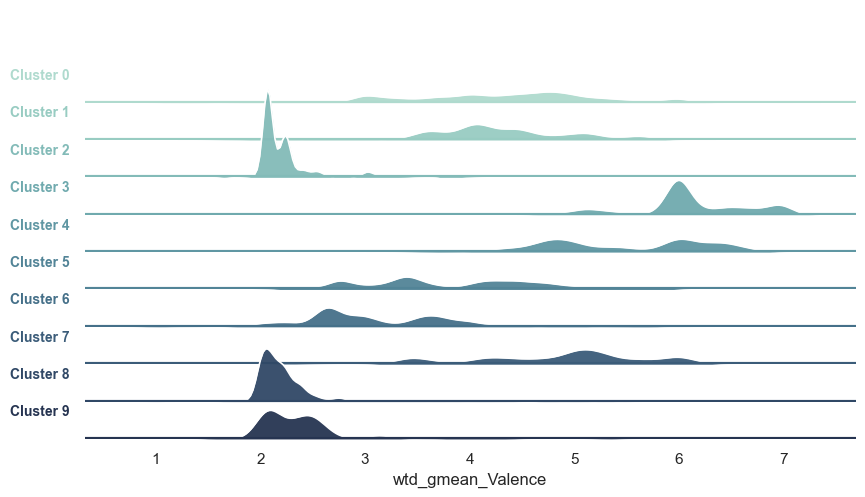

In [237]:
sns.set_theme(
    style="white",
    rc={
        "axes.facecolor": (0, 0, 0, 0),
        "figure.facecolor": "white",
        "axes.linewidth": 0,
        "font.size": 10
    }
)
pal = sns.cubehelix_palette(
    n_colors=len(X_clusters_glm["Cluster"].unique()),
    rot=-0.3,
    light=0.8,
    dark=0.2
)

g = sns.FacetGrid(
    X_clusters_glm,
    row="Cluster",
    hue="Cluster",
    aspect=6,
    height=0.7,
    palette=pal
)

g.map(
    sns.kdeplot,
    "wtd_gmean_Valence",
    bw_adjust=.6,
    fill=True,
    alpha=0.95,
    linewidth=0,
    common_grid=True,
    clip_on=False
)

g.map(
    sns.kdeplot,
    "wtd_gmean_Valence",
    bw_adjust=.6,
    color="white",
    lw=1.2,
    common_grid=True,
    clip_on=False
)

g.refline(
    y=0,
    linewidth=3,
    linestyle="-",
    color=None,
    # alpha=0.4
)

def label(x, color, label):

    ax = plt.gca()

    ax.text(
        -0.02,
        0.25,
        f"Cluster {label}",
        fontweight="bold",
        fontsize=10,
        color=color,
        ha="right",
        transform=ax.transAxes
    )

g.map(label, "wtd_gmean_Valence")

g.set(
    #xlim=(1.5, 3.5),
    yticks=[],
    ylabel="",
    xlabel="wtd_gmean_Valence"
)

g.figure.set_size_inches(10, 5)

g.figure.subplots_adjust(hspace=-0.6)

g.set_titles("")

g.despine(left=True, bottom=True)

# g.figure.suptitle("Ridge Plot: wtd_gmean_Valence por cluster", fontsize=16)

plt.show()


Another possible approach is to use statistical descriptors to better understand the behavior of each formed cluster. We can made this using the dataframe tool ``describe``.

In [238]:
display(X9.describe())

,number_of_elements,mean_atomic_mass,wtd_mean_atomic_mass,gmean_atomic_mass,wtd_gmean_atomic_mass,entropy_atomic_mass,wtd_entropy_atomic_mass,range_atomic_mass,wtd_range_atomic_mass,std_atomic_mass,...,wtd_mean_Valence,gmean_Valence,wtd_gmean_Valence,entropy_Valence,wtd_entropy_Valence,range_Valence,wtd_range_Valence,std_Valence,wtd_std_Valence,Cluster
count,256.000000,256.000000,256.000000,256.000000,256.000000,256.000000,256.000000,256.000000,256.000000,256.000000,...,256.000000,256.000000,256.000000,256.000000,256.000000,256.00000,256.000000,256.000000,256.000000,256.0
mean,4.667969,98.199662,66.861405,67.834992,43.446174,1.199185,1.174503,176.141950,30.852890,67.758615,...,2.638865,2.690900,2.434762,1.326924,1.206326,4.50000,1.089549,1.808802,1.130936,9.0
std,1.440013,16.644809,18.679377,18.468825,18.435250,0.416517,0.425222,7.812519,16.226824,7.925850,...,0.614652,0.462199,0.546044,0.361711,0.359986,0.75667,0.484559,0.346493,0.534332,0.0
min,2.000000,52.975421,17.210566,14.275080,7.682836,0.245779,0.196717,164.948480,7.375385,50.035638,...,1.823660,1.643752,1.616472,0.636514,0.637286,2.00000,0.320000,0.816497,0.216303,9.0
25%,3.000000,88.455650,54.492234,63.112504,31.116766,0.805859,0.741172,167.840600,20.119805,62.159194,...,2.138258,2.289428,2.094562,0.907535,0.817690,4.00000,0.909091,1.549193,0.656149,9.0
50%,5.000000,98.397050,60.241648,72.644022,35.220454,1.398932,1.319921,174.230600,29.009255,69.645778,...,2.453125,2.605171,2.332231,1.455333,1.305209,5.00000,1.003222,1.867109,0.975608,9.0
75%,6.000000,109.084495,78.159579,77.217065,57.993961,1.544972,1.530136,184.590600,38.297896,71.660361,...,2.909091,2.884499,2.512103,1.624223,1.461001,5.00000,1.341920,2.160247,1.743143,9.0
max,7.000000,134.740900,130.358132,96.332876,101.771320,1.785780,1.880860,195.958629,109.608064,90.538650,...,5.516129,4.242641,5.339582,1.847534,1.858150,6.00000,3.838710,2.624669,2.174245,9.0


It´s is possible to visualize this for an unique feature too.

In [239]:
wgv_descriptor_glm = pd.concat([X0.describe()["wtd_gmean_Valence"], 
                            X1.describe()["wtd_gmean_Valence"],
                            X2.describe()["wtd_gmean_Valence"],
                            X3.describe()["wtd_gmean_Valence"],
                            X4.describe()["wtd_gmean_Valence"],
                            X5.describe()["wtd_gmean_Valence"],
                            X6.describe()["wtd_gmean_Valence"],
                            X7.describe()["wtd_gmean_Valence"],
                            X8.describe()["wtd_gmean_Valence"],
                            X9.describe()["wtd_gmean_Valence"]],
                            axis=1)

wgv_descriptor_glm.columns = [f"Cluster {i}" for i in range(10)]

display(wgv_descriptor_glm)


,Cluster 0,Cluster 1,Cluster 2,Cluster 3,Cluster 4,Cluster 5,Cluster 6,Cluster 7,Cluster 8,Cluster 9
count,2444.000000,754.000000,8479.000000,195.000000,296.000000,2852.000000,1047.000000,532.000000,2281.000000,256.000000
mean,4.273566,4.201664,2.284509,6.110509,5.465735,3.878007,3.149135,4.809466,2.260463,2.434762
std,0.935145,0.800454,0.413416,0.533872,0.766609,0.916968,0.760426,0.850591,0.407743,0.546044
min,1.116123,1.587401,1.360790,4.781762,3.443661,1.390389,1.000000,2.239623,1.000000,1.616472
25%,3.693433,3.779763,2.064676,6.000000,4.799789,3.212287,2.631389,4.229485,2.056835,2.094562
50%,4.400559,4.160168,2.119268,6.000000,5.427522,3.786878,3.000000,5.000000,2.153172,2.332231
75%,4.898979,4.643984,2.262322,6.472510,6.024485,4.509991,3.634241,5.348932,2.302237,2.512103
max,7.000000,6.000000,5.961058,7.000000,6.814089,6.201503,6.000000,6.421076,5.488246,5.339582


It is interesting to note that clusters 2, 8, and 9 presented the lowest averages compared to the other clusters, what it is reinforced by the ridge plot for this feature.

Another useful analysis is to investigate the relationship between two or more variables. This because, in some cases, the influence of a feature can be explained by the combination of this atribute with one or more other atributes. 

We can made this by using Shapley Interaction Quantification (``shapiq``)  tool, an python package that implements Shapley Interactions for Machine Learning. This library, based on game theory  - as SHAP (SHapley Additive exPlanations) - can explain feature interections of model predictions, by extending individual Shapley values, quantifying the synergy effect between players. Considering that our model is an hybrid that combines a clustering and a GLM or GAM model, we need to use the agnostic explainer for tabular data. [2]

In [240]:
import sys
sys.path.append('..//Main_Scripts')

from script_glm_interpretability import *

In [241]:
clustering_glm = Clustering_GLM(clusterer=clone(birch_glm),
                    distribution = sm.families.Gaussian(link=Identity())
    )

In [242]:
clustering_glm.fit(X_train, y_train, X_test)

,clusterer,Birch(branchi...1719168858943)
,distribution,<statsmodels....0018D6DD7E620>
,threshold,0.18251719168858943
,branching_factor,700
,n_clusters,10
,compute_labels,True
,copy,'deprecated'


In [243]:
def model_wrapper_glm(x):
    return clustering_glm.predict(x).reshape(-1)

explainer_glm = shapiq.TabularExplainer(
    model=model_wrapper_glm,
    data=X.to_numpy(),
    index="SII",
    max_order=2
)

c:\Users\julia24002\.conda\envs\glm_gam\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
c:\Users\julia24002\.conda\envs\glm_gam\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but Birch was fitted with feature names
  warnings.warn(
c:\Users\julia24002\.conda\envs\glm_gam\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
c:\Users\julia24002\.conda\envs\glm_gam\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but Birch was fitted with feature names
  warnings.warn(


We can use this to identify interactions in the inference of an instance. Let´s use as example the first instance of the train set.

In [244]:
x_instance = X_train.to_numpy()[0].reshape(1, -1)

interaction_values_glm = explainer_glm.explain(x_instance, budget=5096)

c:\Users\julia24002\.conda\envs\glm_gam\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
c:\Users\julia24002\.conda\envs\glm_gam\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but Birch was fitted with feature names
  warnings.warn(
c:\Users\julia24002\.conda\envs\glm_gam\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
c:\Users\julia24002\.conda\envs\glm_gam\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but Birch was fitted with feature names
  warnings.warn(
c:\Users\julia24002\.conda\envs\glm_gam\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature n

In [245]:
print(interaction_values_glm)

InteractionValues(
    index=SII, max_order=2, min_order=0, estimated=True, estimation_budget=3456,
    n_players=81, baseline_value=34.37581146097238,
    Top 10 interactions:
        (np.int64(12), np.int64(22)): 244.2285629140654
        (np.int64(22), np.int64(68)): 233.6772374865674
        (np.int64(18), np.int64(22)): 218.85297133756572
        (np.int64(18), np.int64(54)): 164.43582889681318
        (np.int64(18), np.int64(24)): -157.41057168377534
        (np.int64(14), np.int64(62)): -174.4581901449499
        (np.int64(24), np.int64(62)): -185.7805035674232
        (np.int64(54),): -191.21147839228462
        (np.int64(24), np.int64(68)): -209.05942982126263
        (np.int64(14), np.int64(24)): -277.6695166432878
)


That´s nice! Shapiq was able to identificate some interactions between the features. But what are these features? Let´s discover.

In [246]:
print(f"Feature 12 is {X_train.columns[12]}")
print(f"Feature 14 is {X_train.columns[14]}")
print(f"Feature 18 is {X_train.columns[18]}")
print(f"Feature 22 is {X_train.columns[22]}")
print(f"Feature 24 is {X_train.columns[24]}")
print(f"Feature 54 is {X_train.columns[54]}")
print(f"Feature 62 is {X_train.columns[62]}")
print(f"Feature 68 is {X_train.columns[68]}")

Feature 12 is wtd_mean_fie
Feature 14 is wtd_gmean_fie
Feature 18 is wtd_range_fie
Feature 22 is wtd_mean_atomic_radius
Feature 24 is wtd_gmean_atomic_radius
Feature 54 is wtd_gmean_FusionHeat
Feature 62 is wtd_mean_ThermalConductivity
Feature 68 is wtd_range_ThermalConductivity


Therefore, based on the acronyms, we have that:
* "wtd_mean_fie": WMF
* "wtd_gmean_fie": WGF
* "wtd_range_fie": WRF
* "wtd_mean_atomic_radius": WMAR
* "wtd_gmean_atomic_radius": WGAR
* "wtd_gmean_FusionHeat": WGF
* "wtd_mean_ThermalConductivity": WMT
* "wtd_range_ThermalConductivity": WRT

We can visualize the results using different types of plots, such as the Force plot, which illustrates the strength and direction of the interactions, and the Network plot, which focuses on representing the relationships between features and how they interact with each other.

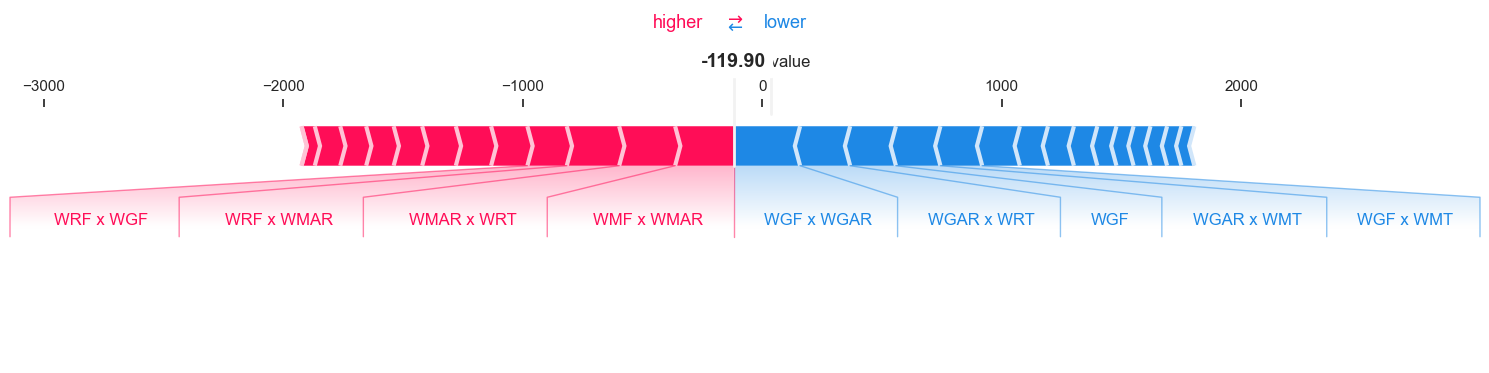

In [247]:
interaction_values_glm.plot_force(feature_names=X_train.columns)

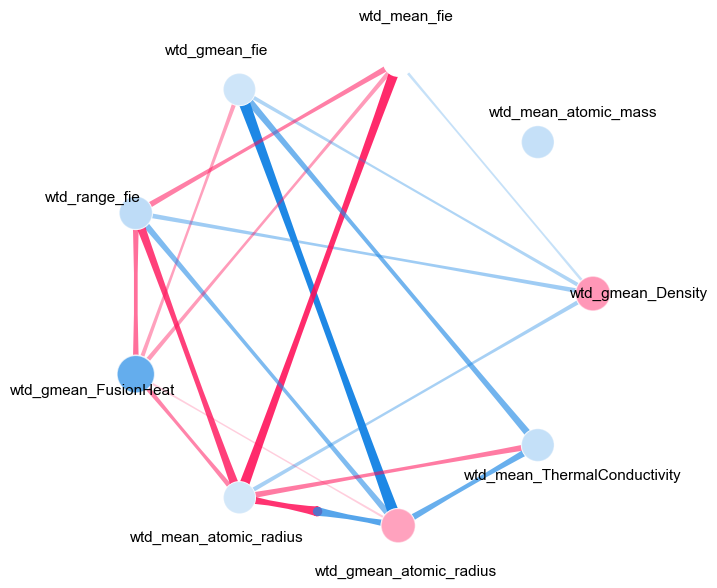

<Figure size 2000x600 with 0 Axes>

In [248]:
shapiq.network_plot(
    interaction_values=interaction_values_glm,
    feature_names=list(X_train.columns),
)
plt.figure(figsize=(20,6))
plt.show()

### **GAM**

So, let’s perform the same analysis for the GAM!

In [249]:
study_name = "optimization_clusters_gam_teste26_10_2025_10_37_18"
storage_url = "sqlite:///../Optuna_files/optimization_clusters_gam_less_clusters.db"

study_gam = optuna.load_study(study_name=study_name, storage=storage_url)

In [250]:
study_gam.best_params

{'clusterer': 'bisecting_kmeans',
 'n_clusters_bkmeans': 6,
 'bisecting_strategy': 'largest_cluster',
 'distribution': 'normal',
 'link_gaussian': 'identity',
 'lam': 1.402388644873421,
 'n_splines': 25}

In [251]:
bkmeans_gam = BisectingKMeans(n_clusters=6,
                            bisecting_strategy="largest_cluster",
                            random_state=1203)

In [252]:
cluster_labels_gam = bkmeans_gam.fit_predict(X_train)

unique_clusters = np.unique(cluster_labels_gam)
valid_clusters = [c for c in unique_clusters if c != -1]

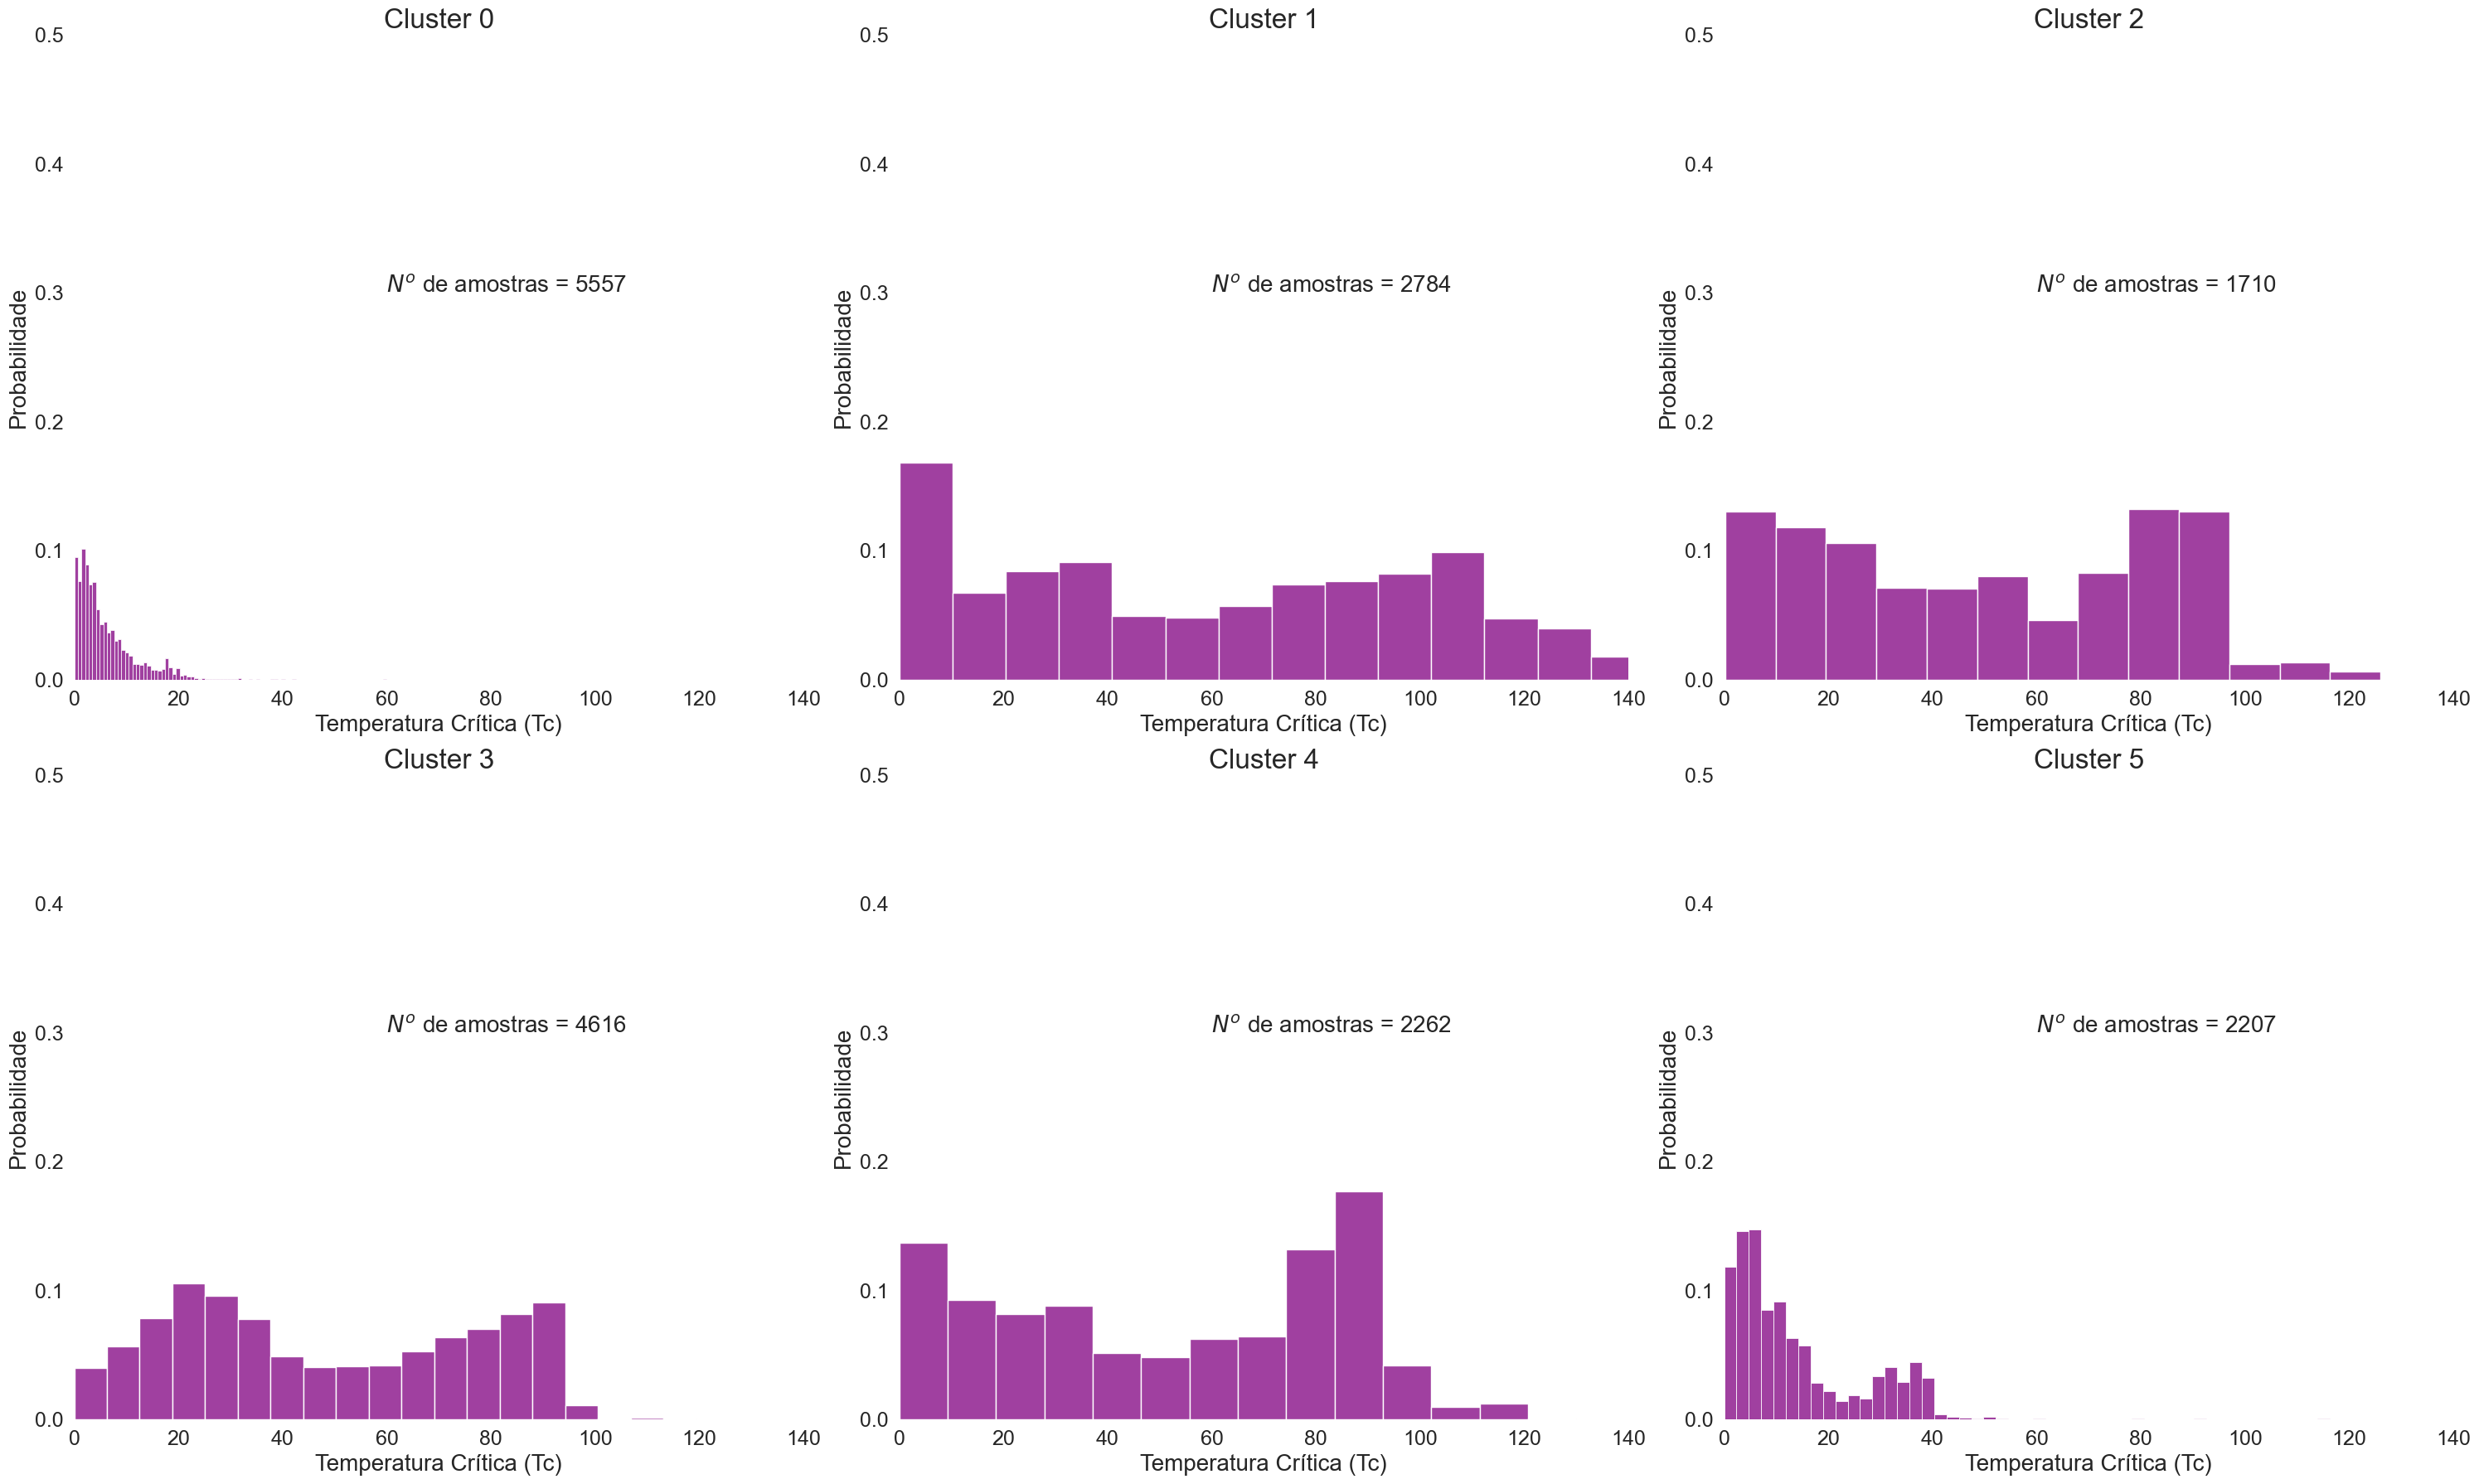

In [253]:
fig, axs = plt.subplots(2, 3, figsize=(30, 18))
axs = axs.flatten()

count = 0
for cluster in valid_clusters: 
    idx = np.where(cluster_labels_gam == cluster)[0]

    axs[count].set_xlabel("Temperatura Crítica (Tc)", fontsize=20)
    axs[count].set_ylabel("Probabilidade", fontsize=20)

    X_cluster = X_train.iloc[idx]
    y_cluster = y_train.iloc[idx]

    sns.histplot(y_cluster, ax=axs[count], kde=False, stat="probability", color="purple") 
    coord_x = max(y_cluster)/2 
    axs[count].annotate(fr"$N^o$ de amostras = {len(y_cluster)}", xy=(60, 0.3), fontsize=20)
    axs[count].set_title(f"Cluster {cluster}", fontsize=24)
    axs[count].set_xlim(0, 140)
    axs[count].set_ylim(0, 0.5)
    axs[count].tick_params(axis='both', labelsize=18) 


    count += 1
    if count >= len(X_train.columns): 
        break

plt.tight_layout()
plt.show()

Most clusters contain superconductors with high critical temperatures - except for 0 and 5.
So it is possible to analyse all of the clusters.

In [254]:
idx0 = np.where(cluster_labels_gam == 0)[0]
Xe0 = Xe_train.iloc[idx0]
# display(Xe0)

idx1 = np.where(cluster_labels_gam == 1)[0]
Xe1 = Xe_train.iloc[idx1]
# display(Xe1)

idx2 = np.where(cluster_labels_gam == 2)[0]
Xe2 = Xe_train.iloc[idx2]
# display(Xe2)

idx3 = np.where(cluster_labels_gam == 3)[0]
Xe3 = Xe_train.iloc[idx3]
# display(Xe3)

idx4 = np.where(cluster_labels_gam == 4)[0]
Xe4 = Xe_train.iloc[idx4]
# display(Xe4)

idx5 = np.where(cluster_labels_gam == 5)[0]
Xe5 = Xe_train.iloc[idx5]
# display(Xe5)

In [255]:
# X0
elements_x0 = {}
for element in Xe.columns:
    elements_x0[element] = 0

for idx in range(len(Xe0)):
    formulas = Xe0.iloc[idx][Xe0.iloc[idx] != 0].index
    for element in formulas:
        elements_x0[element] += 1

# X1
elements_x1 = {}
for element in Xe.columns:
    elements_x1[element] = 0

for idx in range(len(Xe1)):
    formulas = Xe1.iloc[idx][Xe1.iloc[idx] != 0].index
    for element in formulas:
        elements_x1[element] += 1

# X2
elements_x2 = {}
for element in Xe.columns:
    elements_x2[element] = 0

for idx in range(len(Xe2)):
    formulas = Xe2.iloc[idx][Xe2.iloc[idx] != 0].index
    for element in formulas:
        elements_x2[element] += 1

# X3
elements_x3 = {}
for element in Xe.columns:
    elements_x3[element] = 0

for idx in range(len(Xe3)):
    formulas = Xe3.iloc[idx][Xe3.iloc[idx] != 0].index
    for element in formulas:
        elements_x3[element] += 1

# X4
elements_x4 = {}
for element in Xe.columns:
    elements_x4[element] = 0

for idx in range(len(Xe4)):
    formulas = Xe4.iloc[idx][Xe4.iloc[idx] != 0].index
    for element in formulas:
        elements_x4[element] += 1

# X5
elements_x5 = {}
for element in Xe.columns:
    elements_x5[element] = 0

for idx in range(len(Xe5)):
    formulas = Xe5.iloc[idx][Xe5.iloc[idx] != 0].index
    for element in formulas:
        elements_x5[element] += 1

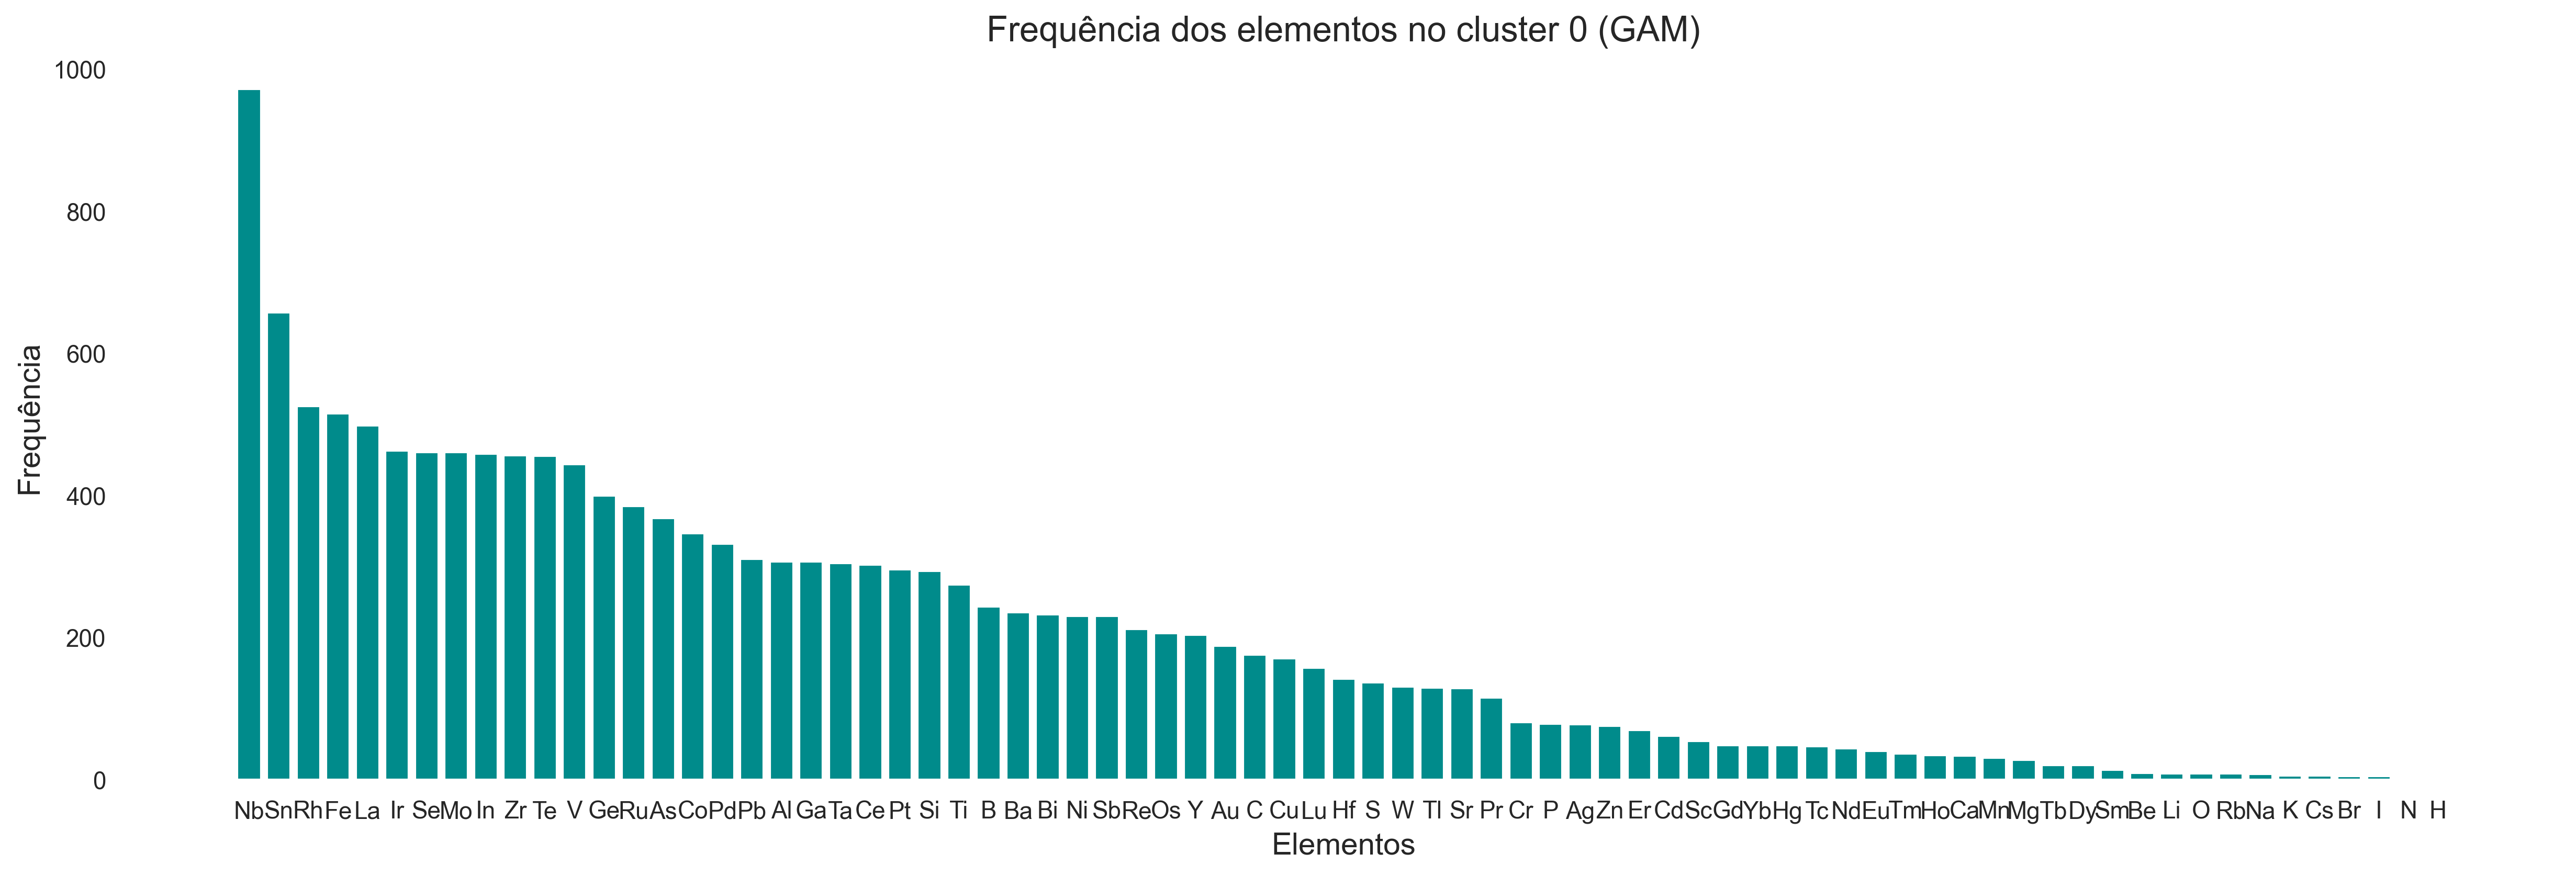

In [256]:
for element in Xe.columns:
    if elements_x0[element] == 0:
        elements_x0.pop(element, None)

elements_x0_ord = dict(sorted(elements_x0.items(), key=lambda item: item[1], reverse=True))

plt.figure(figsize=(20, 6), dpi=300)

plt.bar(elements_x0_ord.keys(), elements_x0_ord.values(), color="darkcyan");
plt.xlabel("Elementos", fontsize=14)
plt.ylabel("Frequência", fontsize=14)
plt.title("Frequência dos elementos no cluster 0 (GAM)", fontsize=16)
plt.show()

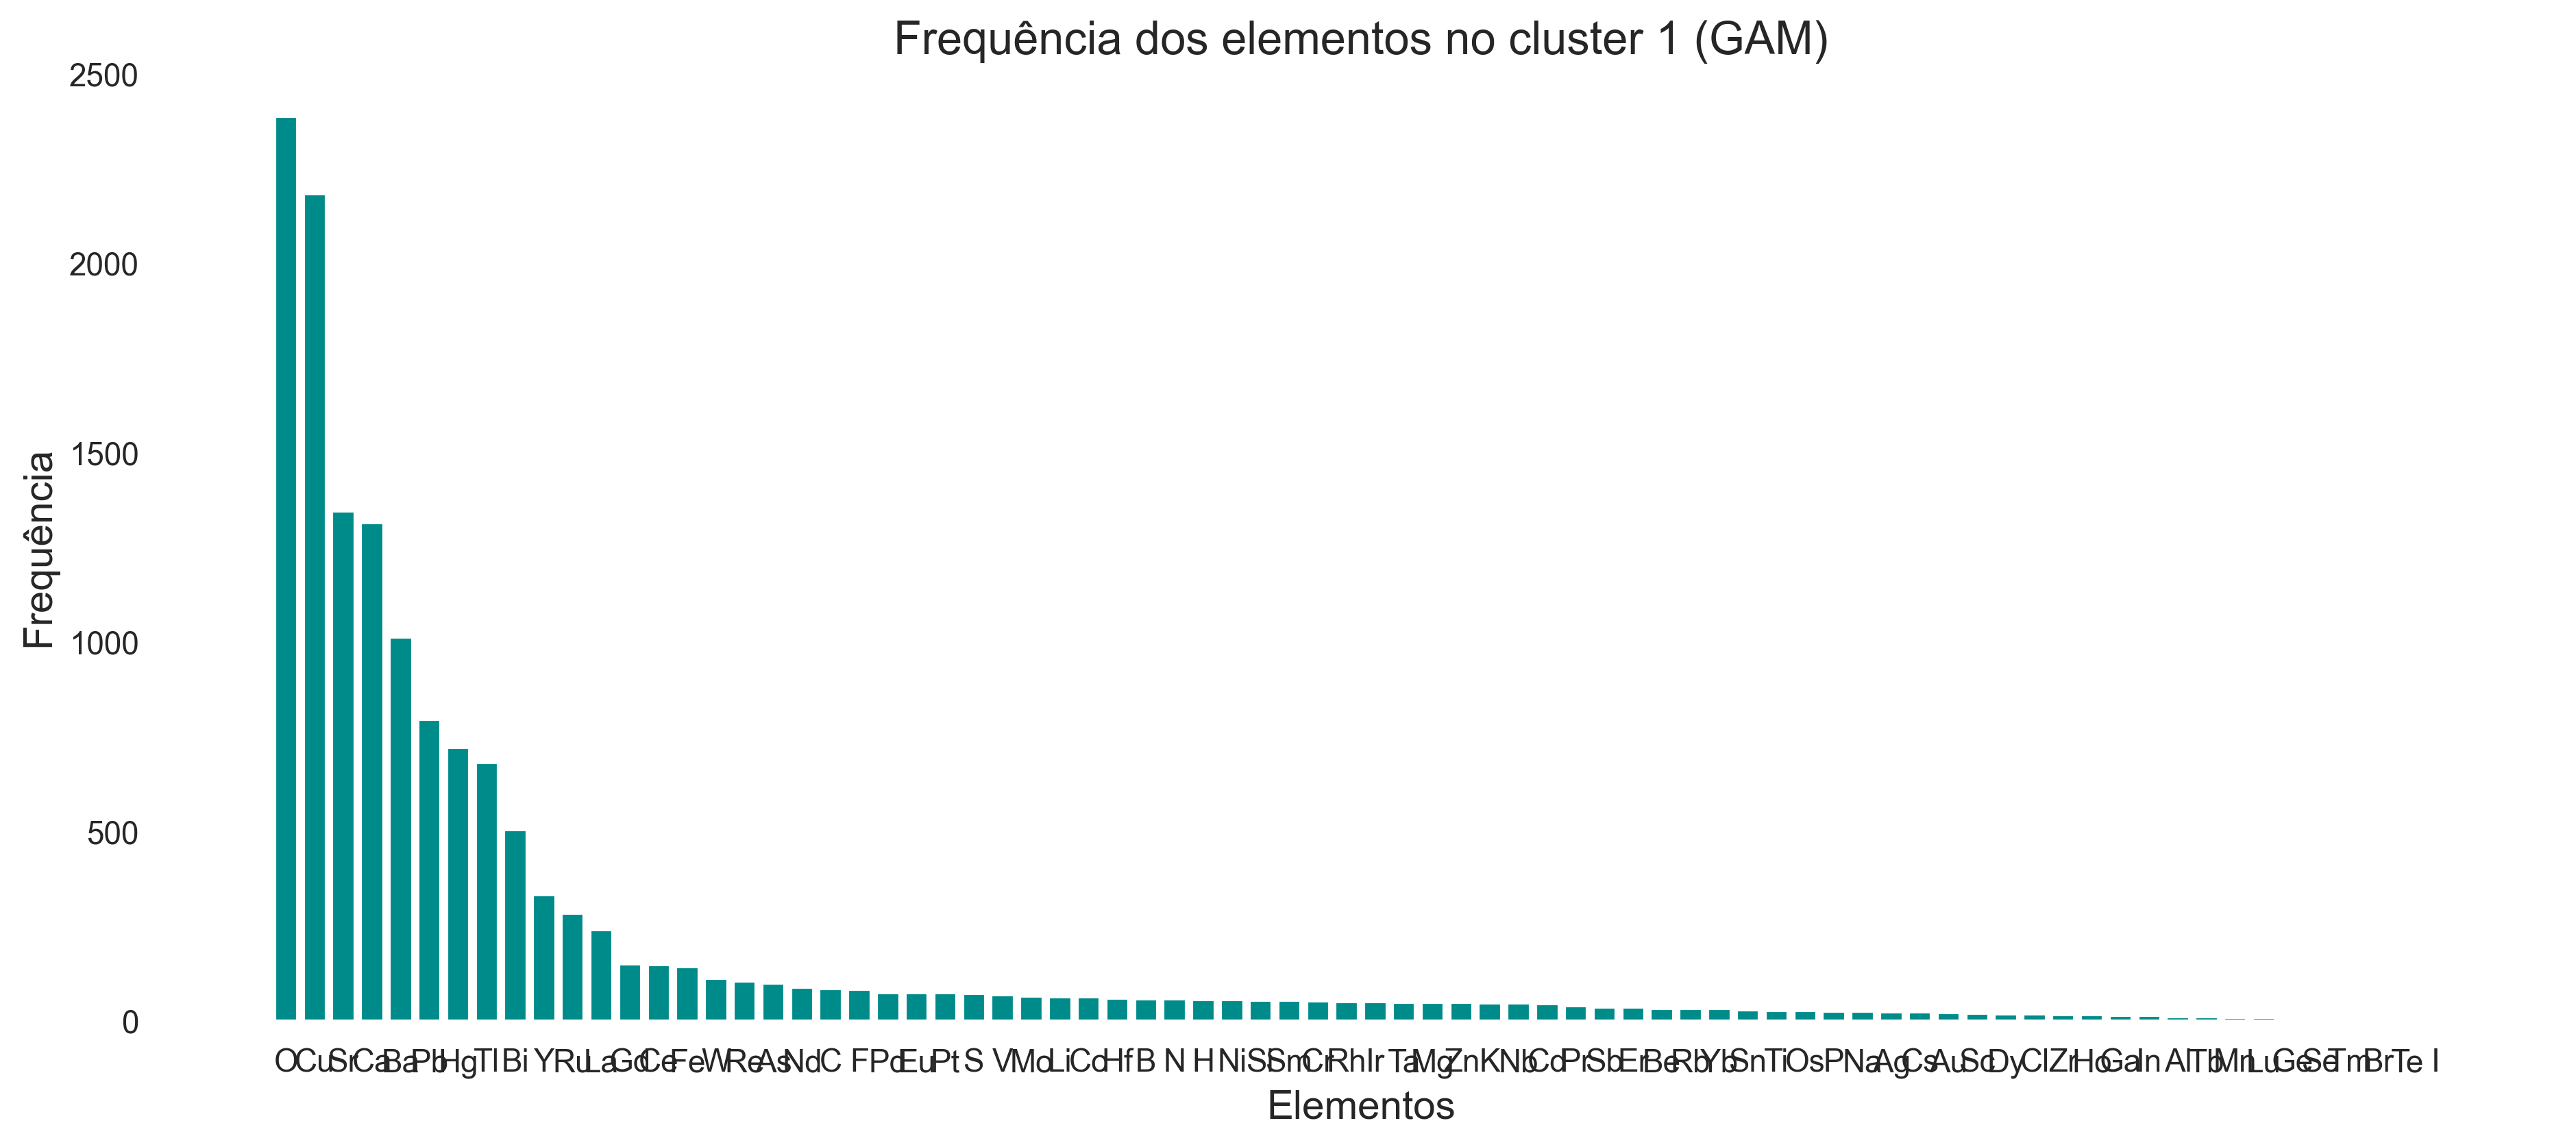

In [257]:
for element in Xe.columns:
    if elements_x1[element] == 0:
        elements_x1.pop(element, None)

elements_x1_ord = dict(sorted(elements_x1.items(), key=lambda item: item[1], reverse=True))

plt.figure(figsize=(15, 6), dpi=300)

plt.bar(elements_x1_ord.keys(), elements_x1_ord.values(), color="darkcyan");
plt.xlabel("Elementos", fontsize=14)
plt.ylabel("Frequência", fontsize=14)
plt.title("Frequência dos elementos no cluster 1 (GAM)", fontsize=16)
plt.show()

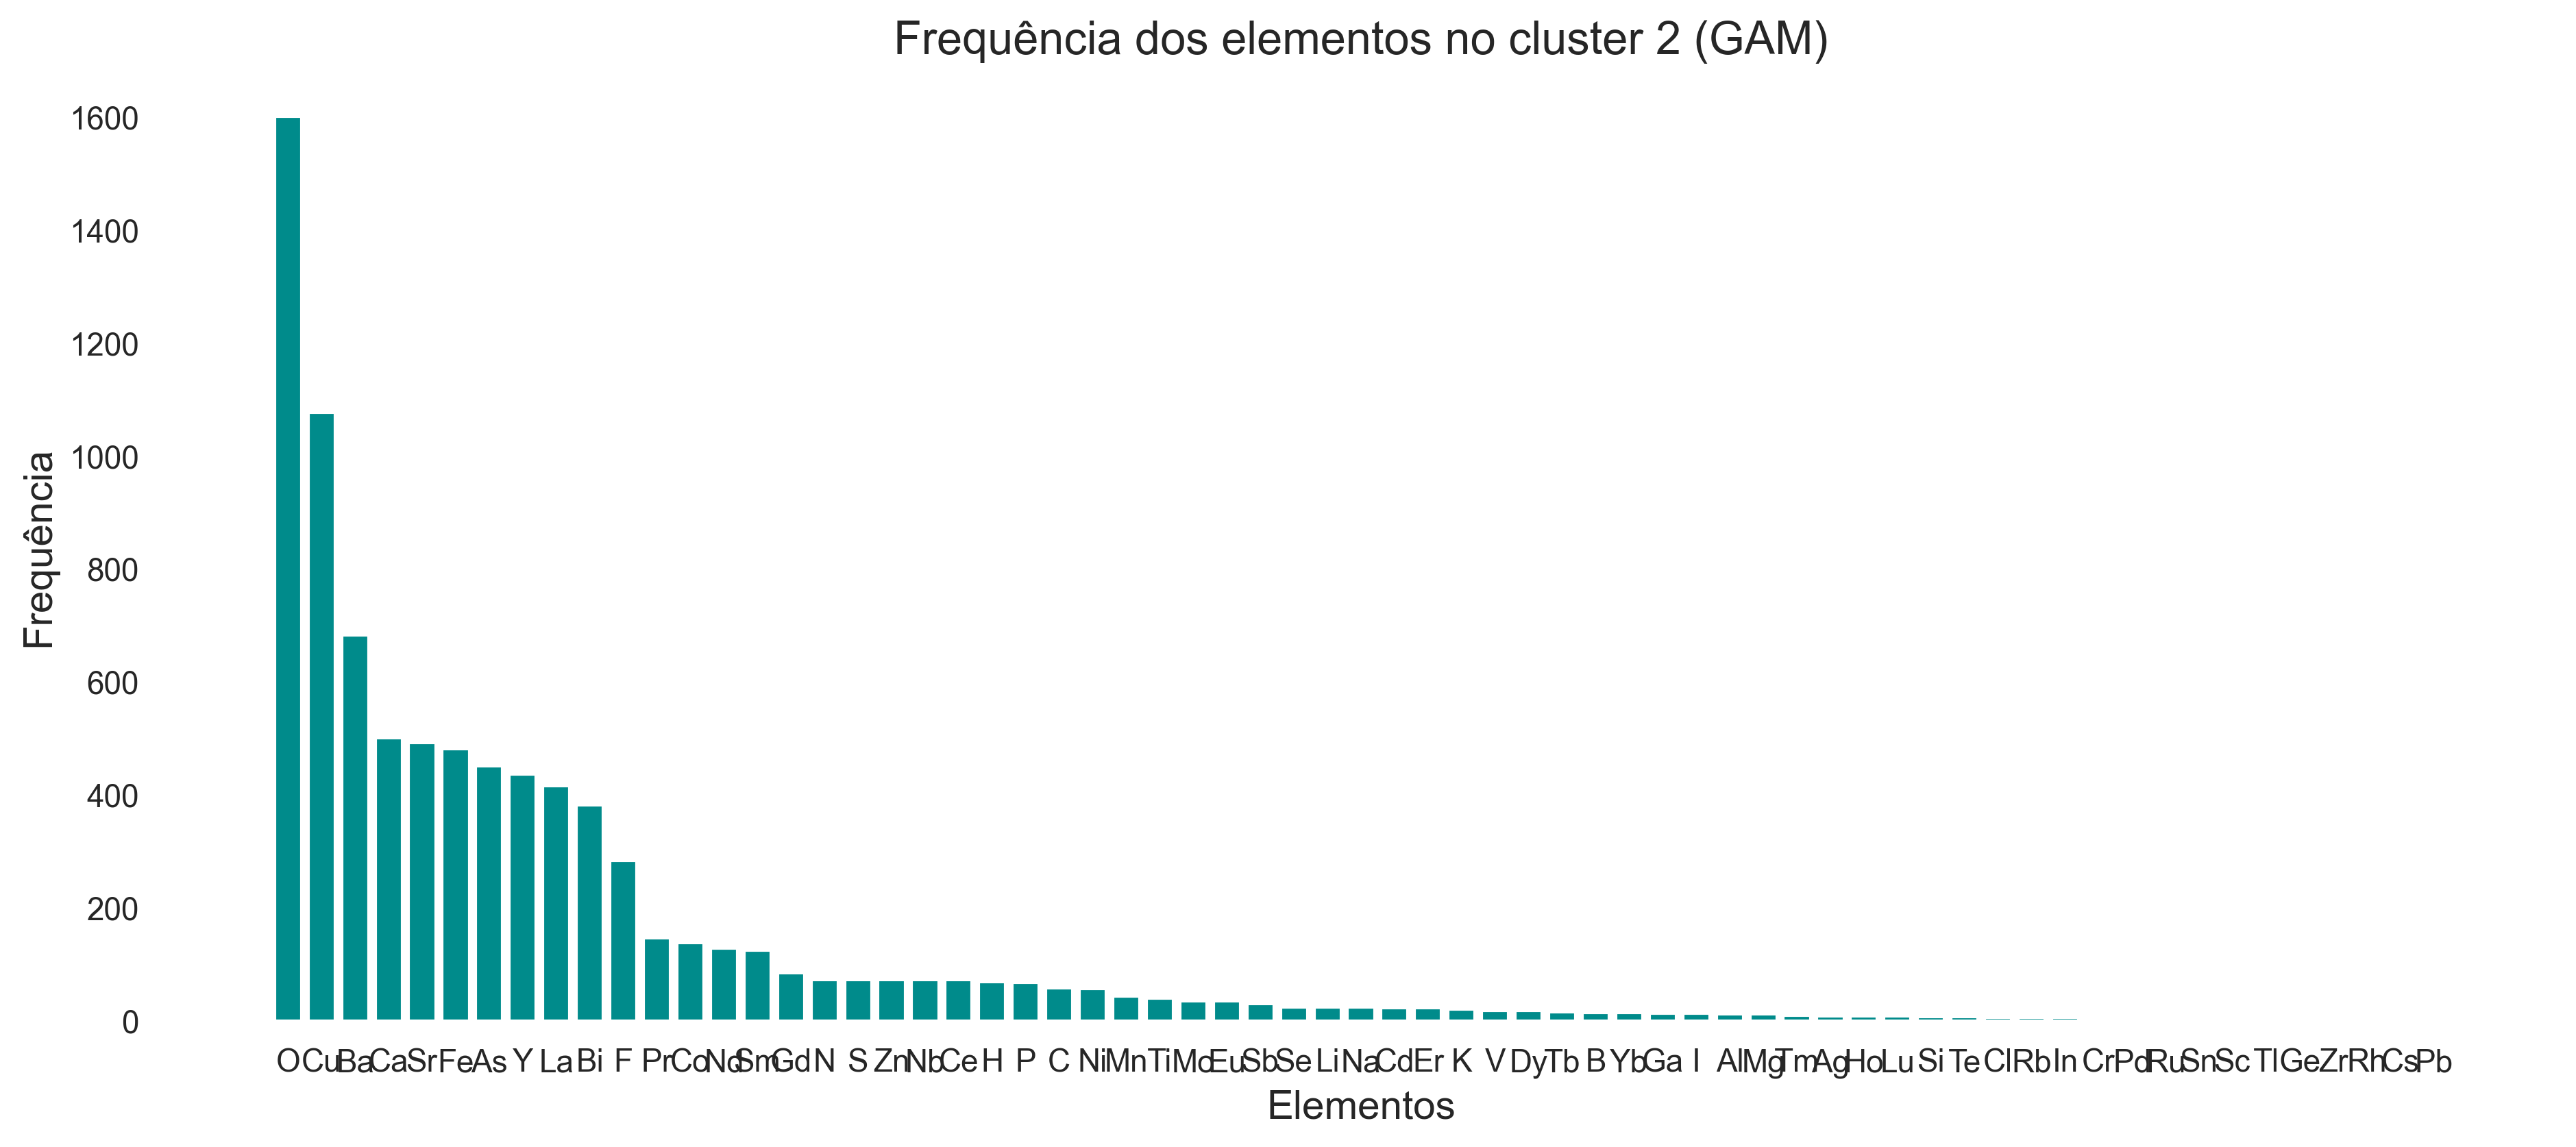

In [258]:
for element in Xe.columns:
    if elements_x2[element] == 0:
        elements_x2.pop(element, None)

elements_x2_ord = dict(sorted(elements_x2.items(), key=lambda item: item[1], reverse=True))

plt.figure(figsize=(15, 6), dpi=300)

plt.bar(elements_x2_ord.keys(), elements_x2_ord.values(), color="darkcyan");
plt.xlabel("Elementos", fontsize=14)
plt.ylabel("Frequência", fontsize=14)
plt.title("Frequência dos elementos no cluster 2 (GAM)", fontsize=16)
plt.show()

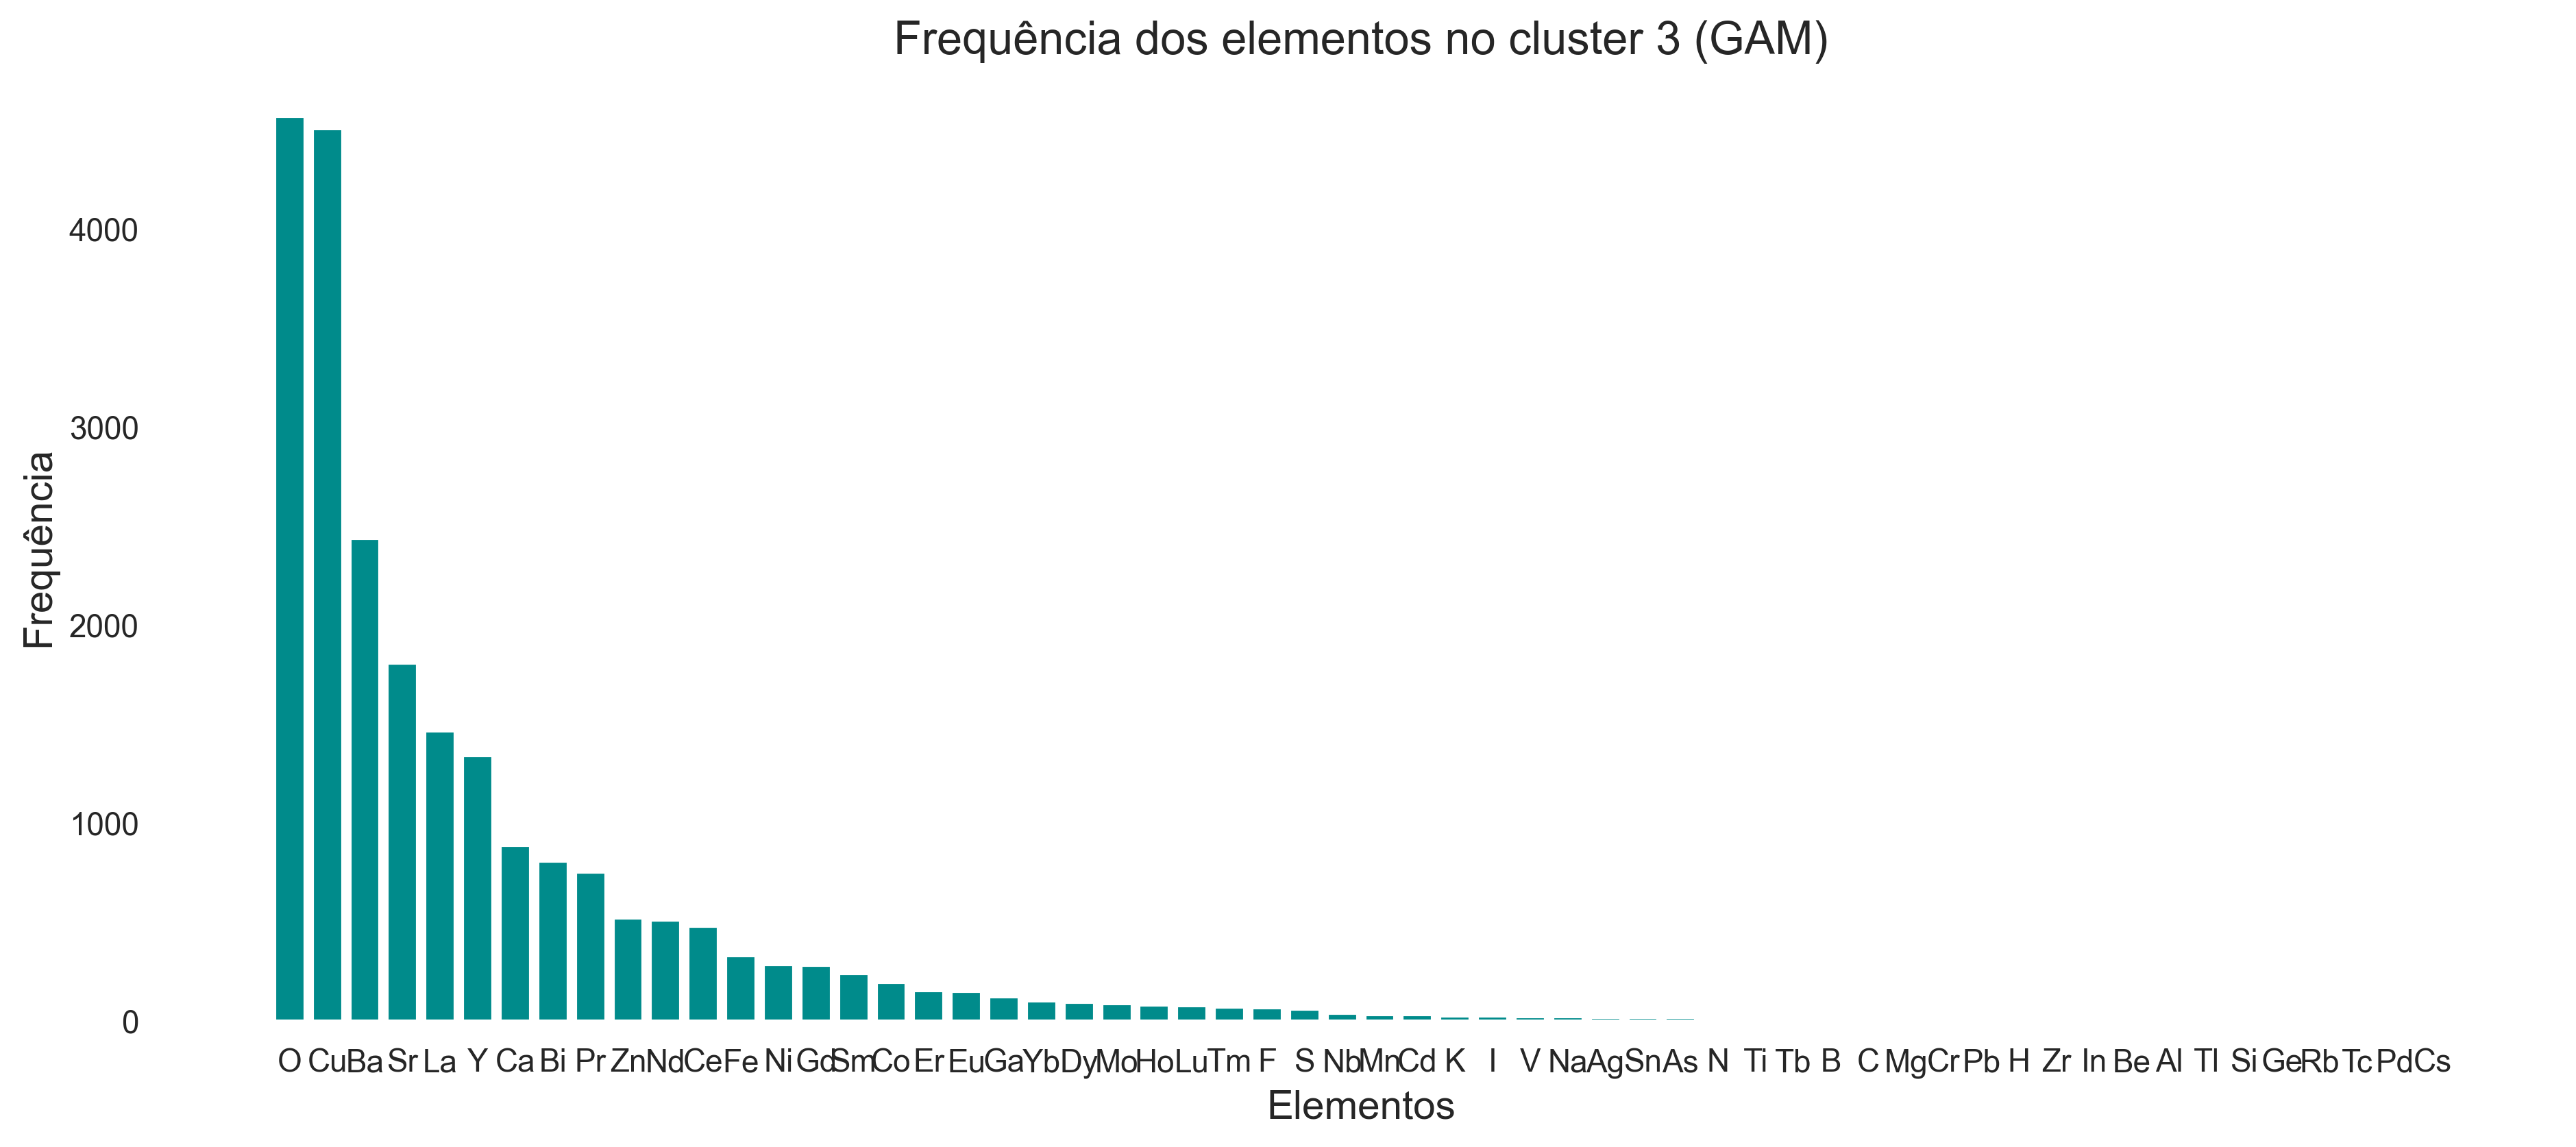

In [259]:
for element in Xe.columns:
    if elements_x3[element] == 0:
        elements_x3.pop(element, None)

elements_x3_ord = dict(sorted(elements_x3.items(), key=lambda item: item[1], reverse=True))

plt.figure(figsize=(15, 6), dpi=300)

plt.bar(elements_x3_ord.keys(), elements_x3_ord.values(), color="darkcyan");
plt.xlabel("Elementos", fontsize=14)
plt.ylabel("Frequência", fontsize=14)
plt.title("Frequência dos elementos no cluster 3 (GAM)", fontsize=16)
plt.show()

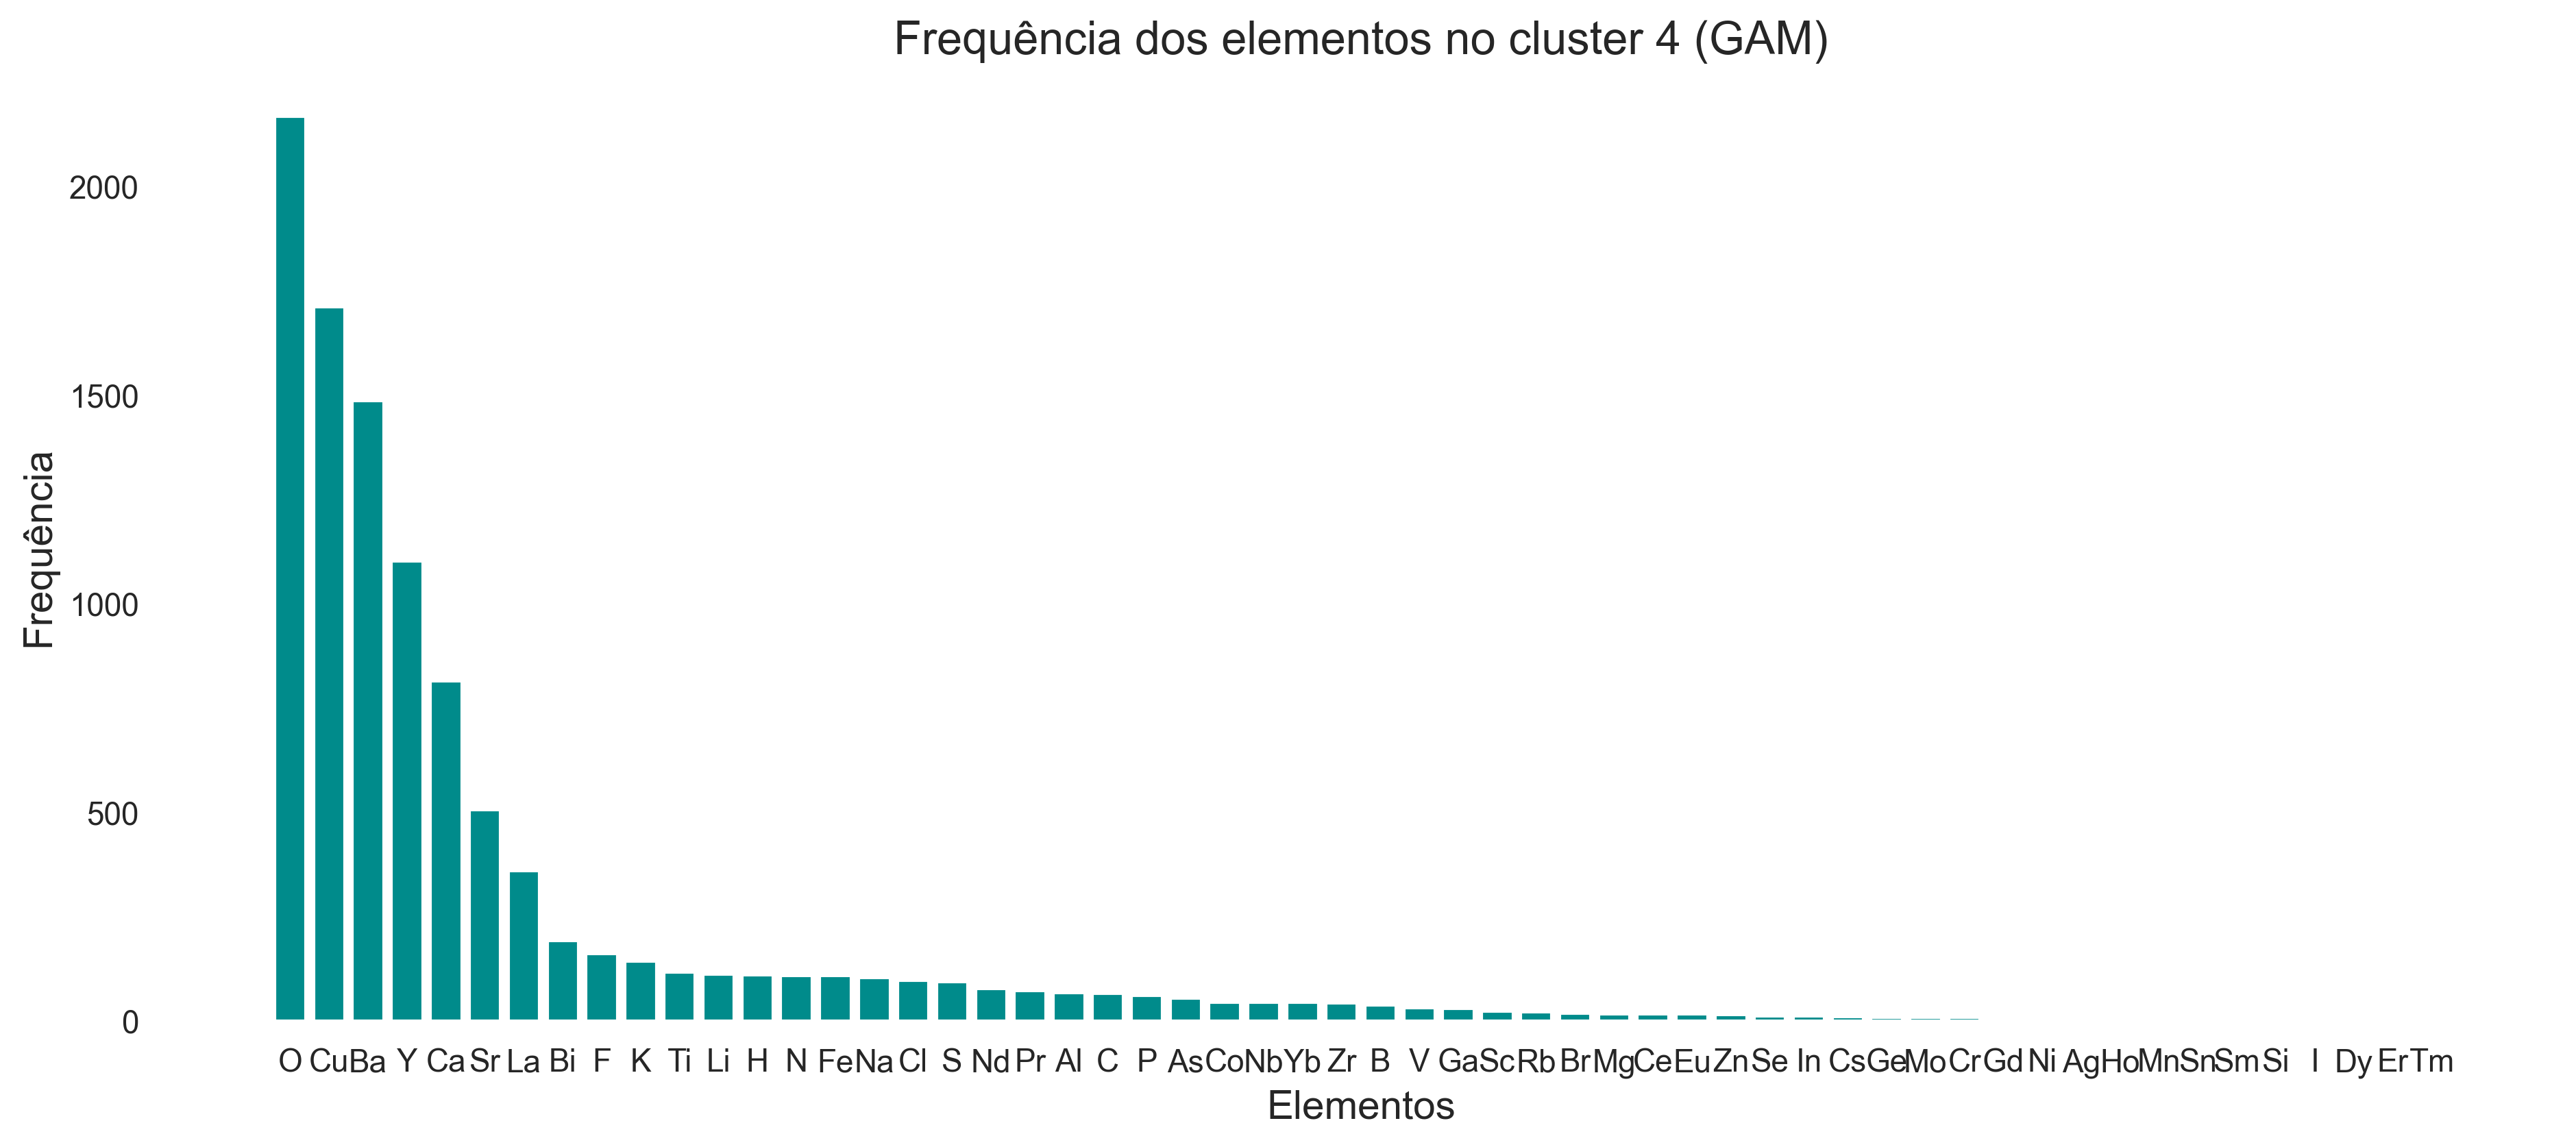

In [260]:
for element in Xe.columns:
    if elements_x4[element] == 0:
        elements_x4.pop(element, None)

elements_x4_ord = dict(sorted(elements_x4.items(), key=lambda item: item[1], reverse=True))

plt.figure(figsize=(15, 6), dpi=300)

plt.bar(elements_x4_ord.keys(), elements_x4_ord.values(), color="darkcyan");
plt.xlabel("Elementos", fontsize=14)
plt.ylabel("Frequência", fontsize=14)
plt.title("Frequência dos elementos no cluster 4 (GAM)", fontsize=16)
plt.show()

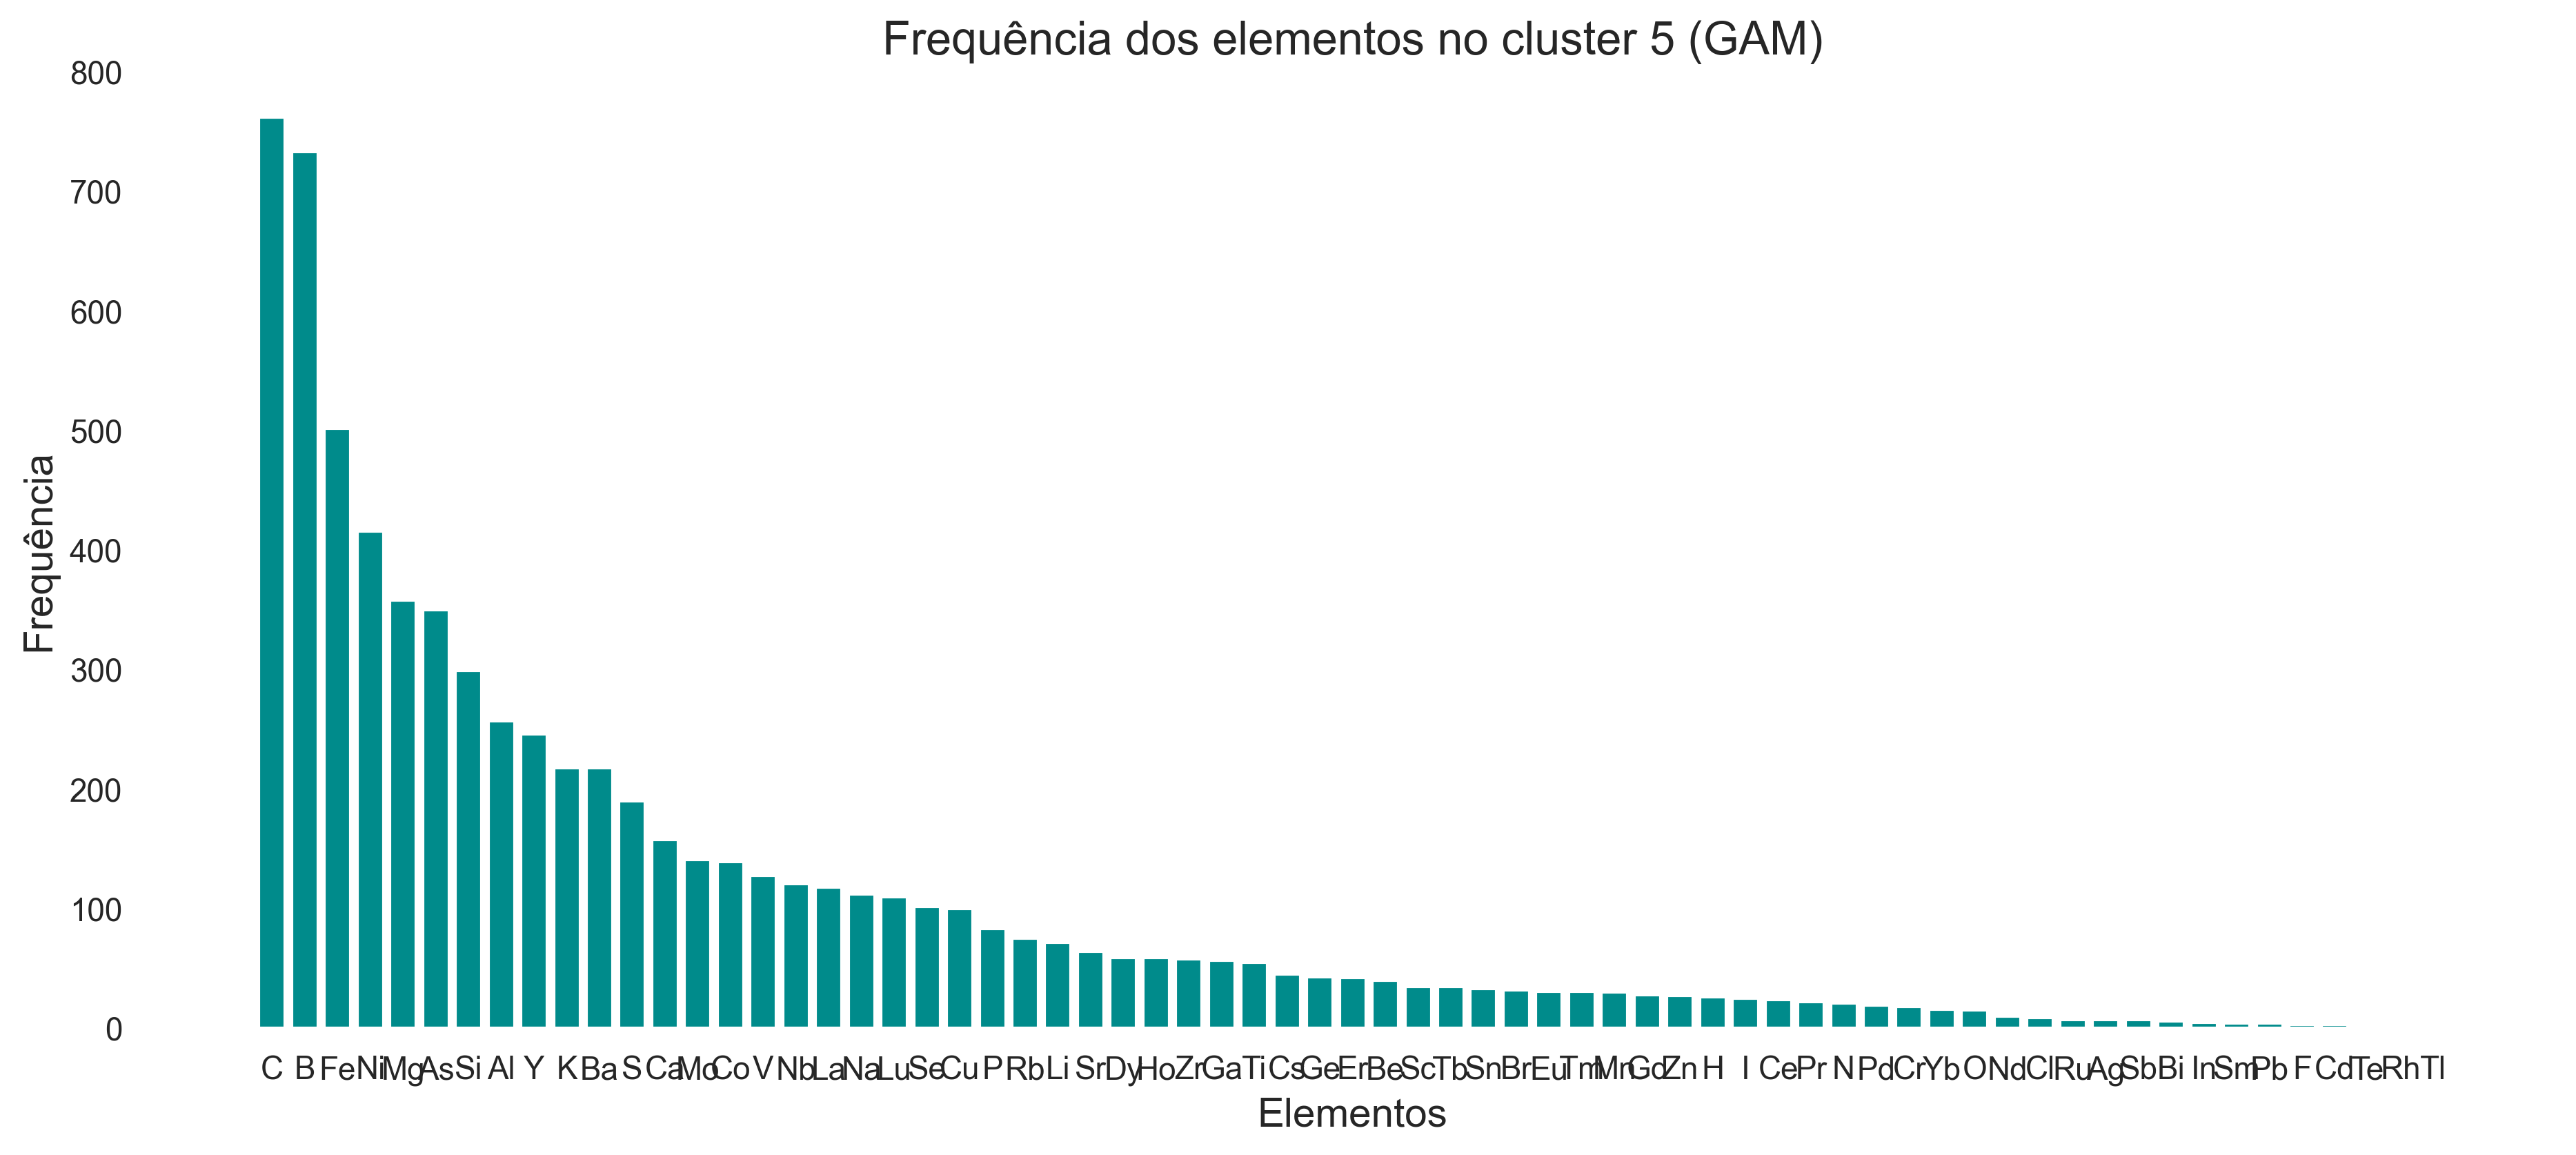

In [261]:
for element in Xe.columns:
    if elements_x5[element] == 0:
        elements_x5.pop(element, None)

elements_x5_ord = dict(sorted(elements_x5.items(), key=lambda item: item[1], reverse=True))

plt.figure(figsize=(15, 6), dpi=300)

plt.bar(elements_x5_ord.keys(), elements_x5_ord.values(), color="darkcyan");
plt.xlabel("Elementos", fontsize=14)
plt.ylabel("Frequência", fontsize=14)
plt.title("Frequência dos elementos no cluster 5 (GAM)", fontsize=16)
plt.show()

In [262]:
idx0 = np.where(cluster_labels_gam == 0)[0]
X0 = X_train.iloc[idx0]
X0["Cluster"] = 0

idx1 = np.where(cluster_labels_gam == 1)[0]
X1 = X_train.iloc[idx1]
X1["Cluster"] = 1

idx2 = np.where(cluster_labels_gam == 2)[0]
X2 = X_train.iloc[idx2]
X2["Cluster"] = 2

idx3 = np.where(cluster_labels_gam == 3)[0]
X3 = X_train.iloc[idx3]
X3["Cluster"] = 3

idx4 = np.where(cluster_labels_gam == 4)[0]
X4 = X_train.iloc[idx4]
X4["Cluster"] = 4

idx5 = np.where(cluster_labels_gam == 5)[0]
X5 = X_train.iloc[idx5]
X5["Cluster"] = 5

C:\Users\julia24002\AppData\Local\Temp\ipykernel_29824\3152094673.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X0["Cluster"] = 0
C:\Users\julia24002\AppData\Local\Temp\ipykernel_29824\3152094673.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X1["Cluster"] = 1
C:\Users\julia24002\AppData\Local\Temp\ipykernel_29824\3152094673.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in

In [263]:
X_clusters_gam = pd.concat([X0,X1, X2, X3, X4, X5], axis=0)

In [264]:
X_clusters_gam

,number_of_elements,mean_atomic_mass,wtd_mean_atomic_mass,gmean_atomic_mass,wtd_gmean_atomic_mass,entropy_atomic_mass,wtd_entropy_atomic_mass,range_atomic_mass,wtd_range_atomic_mass,std_atomic_mass,...,wtd_mean_Valence,gmean_Valence,wtd_gmean_Valence,entropy_Valence,wtd_entropy_Valence,range_Valence,wtd_range_Valence,std_Valence,wtd_std_Valence,Cluster
12566,2,142.455000,142.455000,136.311074,136.311074,0.650334,0.650334,82.770000,41.385000,41.385000,...,6.000000,6.000000,6.000000,0.693147,0.693147,0,0.000000,0.000000,0.000000,0
16819,3,107.077200,122.955287,104.307373,122.810068,1.074136,0.710897,52.678400,63.743545,23.025276,...,5.010152,4.932424,4.909582,1.085189,0.699408,2,2.989848,0.816497,0.997407,0
11653,2,120.334000,173.838000,89.661843,153.370584,0.450338,0.162905,160.512000,160.478667,80.256000,...,2.000000,2.000000,2.000000,0.693147,0.450561,0,1.333333,0.000000,0.000000,0
12961,3,94.748793,94.288485,92.871607,93.580453,1.078804,0.738605,46.080000,61.690485,18.857138,...,4.750000,4.308869,4.728708,1.092831,0.659059,1,3.310000,0.471405,0.433013,0
16855,3,97.270233,62.773350,59.616461,36.229660,0.788125,0.884946,171.829300,32.378650,70.155136,...,5.000000,5.241483,4.898979,1.082196,0.973253,2,1.800000,0.942809,1.000000,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14670,5,81.539890,52.213052,45.848088,30.368619,1.211888,1.369118,156.448000,17.562683,68.840572,...,2.833333,2.930156,2.749459,1.586785,1.473348,2,0.800000,0.632456,0.687184,5
10064,2,17.558000,15.309000,16.209915,14.162583,0.617382,0.691440,13.494000,0.894333,6.747000,...,2.666667,2.449490,2.620741,0.673012,0.562335,1,1.333333,0.500000,0.471405,5
20776,3,58.294333,64.366444,56.117609,62.781285,1.061182,0.882963,38.882000,30.640222,15.967715,...,4.222222,3.301927,3.902534,0.994924,0.809205,4,2.444444,1.699673,1.617802,5
20092,4,72.770842,68.338317,60.286556,62.887682,1.220990,1.163572,114.337231,27.669663,41.643615,...,3.500000,2.340347,3.166208,1.240684,0.951925,4,1.900000,1.479020,1.360147,5


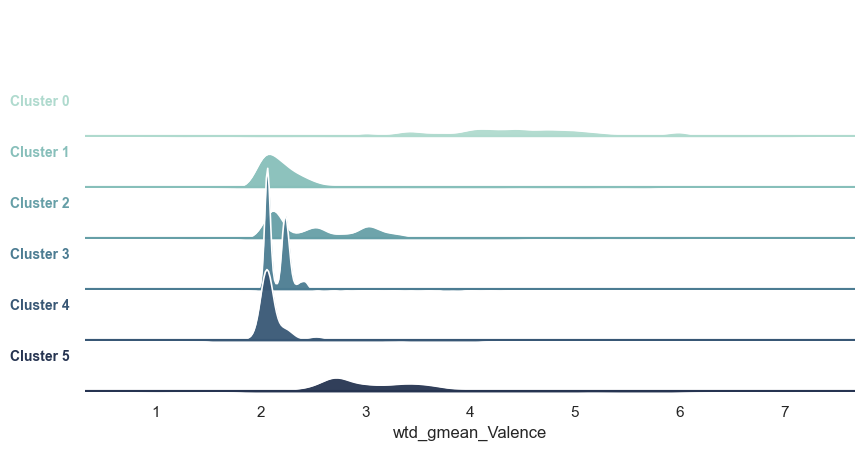

In [265]:
sns.set_theme(
    style="white",
    rc={
        "axes.facecolor": (0, 0, 0, 0),
        "figure.facecolor": "white",
        "axes.linewidth": 0,
        "font.size": 10
    }
)
pal = sns.cubehelix_palette(
    n_colors=len(X_clusters_gam["Cluster"].unique()),
    rot=-0.3,
    light=0.8,
    dark=0.2
)

g = sns.FacetGrid(
    X_clusters_gam,
    row="Cluster",
    hue="Cluster",
    aspect=6,
    height=0.7,
    palette=pal
)

g.map(
    sns.kdeplot,
    "wtd_gmean_Valence",
    bw_adjust=.6,
    fill=True,
    alpha=0.95,
    linewidth=0,
    common_grid=True,
    clip_on=False
)

g.map(
    sns.kdeplot,
    "wtd_gmean_Valence",
    bw_adjust=.6,
    color="white",
    lw=1.2,
    common_grid=True,
    clip_on=False
)

g.refline(
    y=0,
    linewidth=3,
    linestyle="-",
    color=None,
    # alpha=0.4
)

def label(x, color, label):

    ax = plt.gca()

    ax.text(
        -0.02,
        0.25,
        f"Cluster {label}",
        fontweight="bold",
        fontsize=10,
        color=color,
        ha="right",
        transform=ax.transAxes
    )

g.map(label, "wtd_gmean_Valence")

g.set(
    #xlim=(1.5, 3.5),
    yticks=[],
    ylabel="",
    xlabel="wtd_gmean_Valence"
)

g.figure.set_size_inches(10, 5)

g.figure.subplots_adjust(hspace=-0.6)

g.set_titles("")

g.despine(left=True, bottom=True)

# g.figure.suptitle("Ridge Plot: wtd_gmean_Valence por cluster", fontsize=16)

plt.show()

In [266]:
wgv_descriptor_gam = pd.concat([X0.describe()["wtd_gmean_Valence"], 
                            X1.describe()["wtd_gmean_Valence"],
                            X2.describe()["wtd_gmean_Valence"],
                            X3.describe()["wtd_gmean_Valence"],
                            X4.describe()["wtd_gmean_Valence"],
                            X5.describe()["wtd_gmean_Valence"]],
                            axis=1)

wgv_descriptor_gam.columns = [f"Cluster {i}" for i in range(6)]

display(wgv_descriptor_gam)

,Cluster 0,Cluster 1,Cluster 2,Cluster 3,Cluster 4,Cluster 5
count,5557.000000,2784.000000,1710.000000,4616.000000,2262.000000,2207.000000
mean,4.441734,2.408256,2.655708,2.186226,2.231310,3.362156
std,0.942648,0.652617,0.613861,0.213511,0.441223,0.873369
min,1.116123,1.000000,1.360790,1.829359,1.394017,1.000000
25%,3.871005,2.065959,2.125454,2.066061,2.059248,2.749459
50%,4.438940,2.188616,2.517047,2.106799,2.065248,3.166208
75%,5.000000,2.387309,3.027157,2.248725,2.210520,3.743658
max,7.000000,5.646216,5.961058,4.282255,4.090765,7.000000


In [267]:
import sys
sys.path.append('..//Main_Scripts')

from script_gam_interpretability import *

In [268]:
clustering_gam = Clustering_GAM(clone(bkmeans_gam), "normal", "identity", 25, 1.402388644873421)

In [269]:
clustering_gam.fit(X_train, y_train, X_test)

,clusterer,BisectingKMea...om_state=1203)
,distribution,'normal'
,link,'identity'
,n_splines,25
,lam,1.402388644873421
,n_clusters,6
,init,'random'
,n_init,1
,random_state,1203
,max_iter,300
,verbose,0


In [270]:
def model_wrapper_gam(x):
    return clustering_gam.predict(x).reshape(-1)

explainer_gam = shapiq.TabularExplainer(
    model=model_wrapper_gam,
    data=X.to_numpy(),
    index="SII",
    max_order=2
)

c:\Users\julia24002\.conda\envs\glm_gam\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
c:\Users\julia24002\.conda\envs\glm_gam\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but BisectingKMeans was fitted with feature names
  warnings.warn(
c:\Users\julia24002\.conda\envs\glm_gam\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
c:\Users\julia24002\.conda\envs\glm_gam\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but BisectingKMeans was fitted with feature names
  warnings.warn(


In [271]:
interaction_values_gam = explainer_gam.explain(x_instance, budget=5096)

c:\Users\julia24002\.conda\envs\glm_gam\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
c:\Users\julia24002\.conda\envs\glm_gam\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but BisectingKMeans was fitted with feature names
  warnings.warn(
c:\Users\julia24002\.conda\envs\glm_gam\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
c:\Users\julia24002\.conda\envs\glm_gam\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but BisectingKMeans was fitted with feature names
  warnings.warn(
c:\Users\julia24002\.conda\envs\glm_gam\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was f

In [272]:
print(interaction_values_gam)

InteractionValues(
    index=SII, max_order=2, min_order=0, estimated=True, estimation_budget=3456,
    n_players=81, baseline_value=34.379249998088575,
    Top 10 interactions:
        (np.int64(25),): 498.95978006117014
        (np.int64(24),): 245.66759371057253
        (np.int64(12),): 225.94691233083768
        (np.int64(52),): 115.89851754752142
        (np.int64(29),): -130.1825860024622
        (np.int64(16),): -150.23221985911113
        (np.int64(54),): -172.6917835887653
        (np.int64(14),): -201.43398112558629
        (np.int64(22),): -399.86432583599276
        (np.int64(15),): -436.94401598598625
)


In [273]:
print(f"Feature 12 is {X_train.columns[12]}")
print(f"Feature 14 is {X_train.columns[14]}")
print(f"Feature 15 is {X_train.columns[15]}")
print(f"Feature 16 is {X_train.columns[16]}")
print(f"Feature 22 is {X_train.columns[22]}")
print(f"Feature 24 is {X_train.columns[24]}")
print(f"Feature 25 is {X_train.columns[25]}")
print(f"Feature 34 is {X_train.columns[34]}")
print(f"Feature 42 is {X_train.columns[42]}")
print(f"Feature 54 is {X_train.columns[54]}")


Feature 12 is wtd_mean_fie
Feature 14 is wtd_gmean_fie
Feature 15 is entropy_fie
Feature 16 is wtd_entropy_fie
Feature 22 is wtd_mean_atomic_radius
Feature 24 is wtd_gmean_atomic_radius
Feature 25 is entropy_atomic_radius
Feature 34 is wtd_gmean_Density
Feature 42 is wtd_mean_ElectronAffinity
Feature 54 is wtd_gmean_FusionHeat


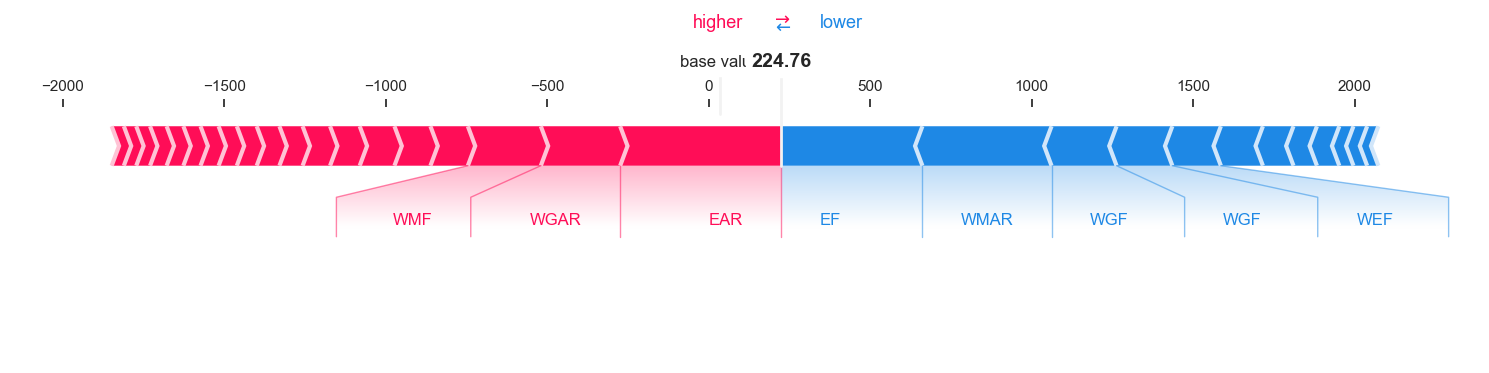

In [274]:
interaction_values_gam.plot_force(feature_names=X_train.columns)

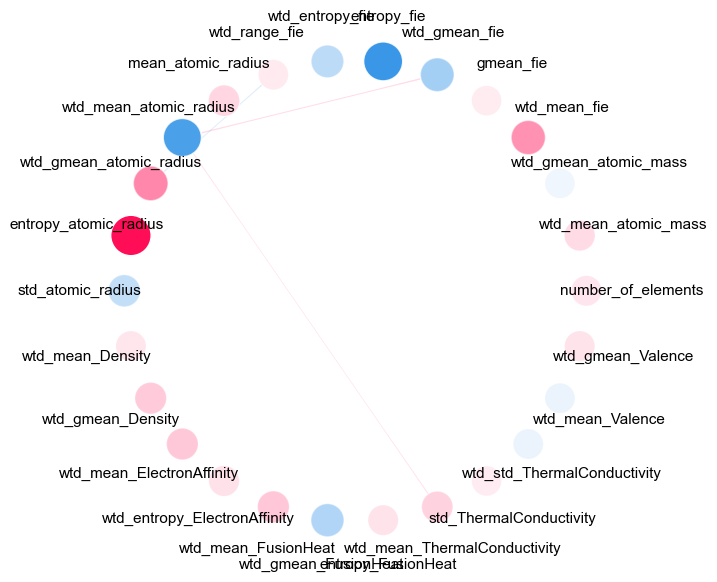

<Figure size 2000x600 with 0 Axes>

In [275]:
shapiq.network_plot(
    interaction_values=interaction_values_gam,
    feature_names=list(X_train.columns),
)
plt.figure(figsize=(20,6))
plt.show()

### 🗂️ **References!**

[1] Overlapping densities (‘ridge plot’) — seaborn 0.13.2 documentation. https://seaborn.pydata.org/examples/kde_ridgeplot.html. Acesso em 24 de fevereiro de 2026.

[2] shapiq 1.4.1 documentation. https://shapiq.readthedocs.io/en/stable/index.html. Acesso em 24 de fevereiro de 2026.
